<a href="https://colab.research.google.com/github/GUNAPILLCO/neural_profit/blob/main/stage_10_strategy/stage_10_strategy_design_fondeo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Stage_10 - Strategy design**

## **Introducción: evaluación bajo reglas reales de fondeo**


Hasta este punto, el desarrollo se centró en construir y validar modelos (LR, GRU) capaces de generar señales predictivas con valor estadístico y operativo. Sin embargo, en un entorno real de trading —y particularmente en pruebas de fondeo— no es suficiente con que una estrategia sea rentable.

El criterio central pasa a ser:

> no solo cuánto gana una estrategia, sino **cómo se comporta su curva de capital en el tiempo**

En este contexto, el control de riesgo está definido principalmente por el **drawdown**, y su forma de medición cambia completamente la viabilidad de una estrategia.




## **Modalidades de control de riesgo**


Se analizarán dos esquemas utilizados por empresas de fondeo:

* **Trailing Drawdown intradía**

  Es un límite de pérdida dinámico que:

  * se actualiza en tiempo real
  * sigue el máximo alcanzado por la cuenta
  * se evalúa en todo momento

  **Interpretación simple:**

  > la cuenta es evaluada continuamente, sin margen para retrocesos

  **Ejemplo:**

  * Capital inicial: 50,000 → límite: 48,000
  * La cuenta sube a 51,000 → nuevo límite: 49,000
  * La cuenta baja a 48,900 → se pierde la cuenta

  Esto ocurre incluso si la estrategia era rentable previamente.

  **Implicancias operativas:**

  * penaliza la volatilidad intradía
  * no permite “respirar” a las operaciones
  * exige alta precisión en el timing

* **Drawdown End of Day (EOD)**

  Es un límite de pérdida que:

  * se evalúa únicamente al cierre del día
  * ignora las fluctuaciones intradía
  * considera solo el resultado final diario

  **Interpretación simple:**

  > solo importa dónde termina la cuenta al final del día

  **Ejemplo:**

  * Durante el día la cuenta cae por debajo del límite
  * Pero cierra por encima del mismo
    → la cuenta permanece activa

  **Implicancias operativas:**

  * permite variabilidad intradía
  * tolera retrocesos temporales
  * es más compatible con estrategias sistemáticas


## **Diferencia conceptual clave**

* **Trailing intradía:** castiga el recorrido de la equity
* **EOD:** evalúa el resultado final

Esto es consistente con el principio de evaluación de estrategias:

> una estrategia debe ser evaluada no solo por su retorno, sino por su perfil de riesgo y trayectoria de pérdidas

## **Conexión con los modelos desarrollados**

Los modelos LR y GRU:

* generan probabilidades de señal
* operan con múltiples trades
* presentan aciertos distribuidos en el tiempo
* tienen variabilidad intratrade

Por lo tanto:

* bajo trailing intradía → existe riesgo elevado de invalidación por ruido
* bajo EOD → la estrategia puede expresar su edge acumulativo

## **Enfoque del nuevo análisis**

El objetivo ya no es validar modelos desde métricas de clasificación, sino:

> evaluar su comportamiento como sistemas de trading bajo restricciones reales

Esto implica incorporar una nueva capa sobre el pipeline existente:

* simulación de PnL
* construcción de equity curve
* evaluación de drawdown
* validación contra reglas de fondeo

## **Plan de trabajo completo: de modelos a evaluación bajo fondeo**


El flujo general sigue el proceso estándar:

> señal → estrategia → simulación → evaluación

Pero ahora el objetivo final cambia hacia validación bajo condiciones reales de riesgo.

---

**2. Selección de datos OOS para diseño de estrategia**

- Se definen los datasets fuera de muestra (VALID / TEST) que se utilizarán para construir y evaluar estrategias.
- Objetivo: trabajar únicamente con datos que representen comportamiento real no visto.

---

**3. Separación GRU / Logistic Regression**

- Se separan los outputs de cada modelo.
- Objetivo: analizar cada modelo de forma independiente antes de combinarlos.

---

**4. Dataset comparativo GRU vs LR**

- Se construye un dataset unificado con ambas predicciones alineadas.
- Objetivo: permitir comparaciones directas muestra a muestra.

---

**5. Análisis de actividad**

- Se evalúa:

  * cantidad de trades
  * frecuencia de señal

- Objetivo: entender el perfil operativo (activo vs conservador).

---

**6. Análisis de distribución de probabilidades GRU vs LR**

- Se estudian las probabilidades generadas por cada modelo.
- Objetivo: entender la “confianza” de las señales.

---

**7. Construcción y comparación de estrategias sobre VALID**

- Se aplican reglas de trading (thresholds) para generar señales reales.

- Objetivo: transformar probabilidades en decisiones operativas.

---

**8. Barrido de thresholds para GRU baseline**

- Se prueban distintos umbrales de entrada.

- Objetivo: evaluar el trade-off entre:

  * cantidad de trades
  * precisión

- **Observaciones generales**

  * Se sintetizan patrones observados en los puntos anteriores.
  * Objetivo: identificar comportamientos estructurales del modelo.

---

**9. Selección y comparación de configuraciones candidatas**

- Se eligen las mejores configuraciones (thresholds / modelos).
- Objetivo: reducir el espacio a estrategias viables.

---

**10. Validación en TEST OOS**

- Se evalúan las estrategias seleccionadas en datos completamente fuera de muestra.
- Objetivo: confirmar robustez.

---

**12. Evaluación operativa de las señales (PnL)**

- Se simulan resultados económicos por trade.
- Objetivo: pasar de métricas predictivas a resultados monetarios.

---

**13. Cálculo de PnL por estrategia**

- Se calcula:

  * PnL total
  * PnL promedio
  * distribución de resultados

- Objetivo: cuantificar el rendimiento económico.

* Observaciones

  - Análisis cualitativo del comportamiento del PnL.
  - Objetivo: detectar patrones de riesgo o inestabilidad.

---

**13. Simulación bajo reglas de fondeo**

Se redefine la evaluación incorporando restricciones reales.

---

**13.1 Escenario Trailing Drawdown intradía**

  - Se simula la cuenta considerando:

    * drawdown dinámico en tiempo real
    * equity minuto a minuto
    * máximos alcanzados
    * puntos de ruptura de cuenta

  - Objetivo: evaluar si la estrategia sobrevive bajo condiciones estrictas.

---

**13.2 Escenario Drawdown End of Day (EOD)**

  - Se simula considerando:

    * equity al cierre diario
    * drawdown basado en cierre
    * variabilidad intradía ignorada

  - Objetivo: evaluar estabilidad bajo condiciones más flexibles.

---

**14. Optimización operativa y gestión de riesgo**

- El foco cambia de maximizar PnL a:

  * controlar drawdown
  * mejorar consistencia
  * asegurar supervivencia

---

**14.1 Análisis por contexto de mercado**

- Se evalúa performance según condiciones del mercado.
- Objetivo: entender cuándo funciona mejor la estrategia.

  ---

  - 14.1.1. Desempeño por tipo de operación (long vs short)

    - Se separa el rendimiento por dirección.
    - Objetivo: detectar asimetrías.

  ---

  - 14.1.2 Desempeño intra-hora (opening)

    - Se analiza el comportamiento dentro del opening.
    - Objetivo: identificar ventanas óptimas de operación.

---

**14.2 Filtro de calidad de operaciones**

  ---

  - 15.2.1 Desempeño por nivel de probabilidad (confidence bins)

    - Se agrupan trades según confianza del modelo.
    - Objetivo: validar que mayor probabilidad implica mejor resultado.

  ---

  - 14.2.2 Aplicación de probabilidad mínima

    - Se eliminan trades de baja calidad.
    - Objetivo: reducir ruido.

  ---

  - 14.2.3 Optimización de thresholds

    - Se ajustan umbrales finales.
    - Objetivo: balancear:

      * precisión
      * frecuencia
      * riesgo

---

**14.3 Tamaño de posición**

  - Se evalúa impacto de contratos por trade.
  - Objetivo: controlar riesgo total.

---

**14.4 Gestión de riesgo**

  - Se definen reglas como:

    * stop loss por trade
    * límite diario
    * control de rachas

  - Objetivo: adaptar la estrategia a reglas reales de fondeo.


**Idea clave del framework**

El proceso evoluciona desde:

> validar modelos predictivos

hacia:

> validar sistemas de trading que sobreviven bajo restricciones reales

---

**Objetivo final**

Determinar, usando datos OOS:

* si las estrategias sobreviven
* bajo qué condiciones
* con qué configuración
* y en qué tipo de prop firm son viables

# **1. Cargar entorno, librerías y rutas del proyecto**

## **1.1. Entorno**

In [1]:
# Permite anotaciones modernas en Python < 3.11
from __future__ import annotations

# ================================
# Standard library (mínimo necesario)
# ================================
import os
import sys
import warnings
import logging
from pathlib import Path

# ================================
# Third-party
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Configuración global
# ================================

# ---- Warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# ---- Logging limpio
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
logger.propagate = False

if logger.handlers:
    logger.handlers.clear()

handler = logging.StreamHandler()
formatter = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
handler.setFormatter(formatter)
logger.addHandler(handler)

logger.info("Environment initialized")

# ---- Pandas display
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

# ---- Estilo plots
sns.set(style="whitegrid")

2026-05-24 19:09:01,690 | INFO | Environment initialized


## **1.2. Acceso a drive**

In [2]:
# ================================
# Entorno (Google Drive / local)
# ================================

from pathlib import Path
import os

# Detectar si estamos en Colab
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

    DEFAULT_DRIVE_DIR = "/content/drive/MyDrive/neural_profit/"
else:
    # fallback local (puedes ajustarlo si quieres)
    DEFAULT_DRIVE_DIR = "./neural_profit/"

# Ruta base del proyecto
DRIVE_DIR = Path(os.environ.get("DRIVE_DIR", DEFAULT_DRIVE_DIR))

# Validación básica
if not DRIVE_DIR.exists():
    logger.warning(f"DRIVE_DIR no existe: {DRIVE_DIR}")
else:
    logger.info(f"DRIVE_DIR: {DRIVE_DIR}")

2026-05-24 19:09:18,973 | INFO | DRIVE_DIR: /content/drive/MyDrive/neural_profit


Mounted at /content/drive


## **1.3. Rutas de métricas y probabilidades**

In [3]:
# =========================================
# Base path
# =========================================
BEST_MODELS_DIR = Path("/content/drive/MyDrive/neural_profit/best_models")

# =========================================
# Paths de modelos
# =========================================
LR_FINAL_BALANCED_DIR = BEST_MODELS_DIR / os.environ.get(
    "LR_FINAL_BALANCED_DIR",
    "lr_final_balanced/"
)

GRU_FINAL_BASELINE_DIR = BEST_MODELS_DIR / os.environ.get(
    "GRU_FINAL_BASELINE_DIR",
    "gru_final_baseline/"
)



In [4]:
METRICS_OOS_DIR = BEST_MODELS_DIR / os.environ.get(
    "METRICS_OOS_DIR",
    "df_metrics_oos_valid_test.parquet"
)

PROBA_OOS_DIR = BEST_MODELS_DIR / os.environ.get(
    "PROBA_OOS_DIR",
    "df_probabilities_oos_valid_test.parquet"
)

# **2. Cargar datasets OOS de probabilidades y métricas.**

In [5]:
# =========================================================
# 2.1. Carga de datasets OOS (post modelo final)
# =========================================================

# Rutas relativas a BEST_MODELS_DIR
METRICS_OOS_DIR = BEST_MODELS_DIR / os.environ.get(
    "METRICS_OOS_DIR",
    "df_metrics_oos_valid_test.parquet"
)

PROBA_OOS_DIR = BEST_MODELS_DIR / os.environ.get(
    "PROBA_OOS_DIR",
    "df_probabilities_oos_valid_test.parquet"
)

# -------------------------------
# Validación de existencia
# -------------------------------
assert METRICS_OOS_DIR.exists(), f"No existe: {METRICS_OOS_DIR}"
assert PROBA_OOS_DIR.exists(), f"No existe: {PROBA_OOS_DIR}"

logger.info(f"Cargando métricas OOS desde: {METRICS_OOS_DIR}")
logger.info(f"Cargando probabilidades OOS desde: {PROBA_OOS_DIR}")

# -------------------------------
# Carga de datos
# -------------------------------
df_metrics_oos = pd.read_parquet(METRICS_OOS_DIR)
df_prob_oos = pd.read_parquet(PROBA_OOS_DIR)

# -------------------------------
# Inspección básica
# -------------------------------
print("=" * 80)
print("DATASETS OOS CARGADOS")
print("=" * 80)

print("df_metrics_oos:", df_metrics_oos.shape)
print("df_prob_oos   :", df_prob_oos.shape)

print("\nColumnas df_prob_oos:")
print(df_prob_oos.columns.tolist())

print("\nSplits disponibles:", df_prob_oos["split"].unique())
print("Targets disponibles:", df_prob_oos["target"].unique())
print("Modelos disponibles:", df_prob_oos["model"].unique())

print("=" * 80)

2026-05-24 19:09:19,306 | INFO | Cargando métricas OOS desde: /content/drive/MyDrive/neural_profit/best_models/df_metrics_oos_valid_test.parquet
2026-05-24 19:09:19,307 | INFO | Cargando probabilidades OOS desde: /content/drive/MyDrive/neural_profit/best_models/df_probabilities_oos_valid_test.parquet


DATASETS OOS CARGADOS
df_metrics_oos: (6, 34)
df_prob_oos   : (41385, 18)

Columnas df_prob_oos:
['proba_-1', 'proba_0', 'proba_1', 'pred_label', 'confidence', 'y_true', 'is_correct', 'signal_raw', 'trade', 'experiment_name', 'model', 'split', 'window_size', 'target', 'horizon', 'threshold_long', 'threshold_short', 'class_labels']

Splits disponibles: ['test' 'valid']
Targets disponibles: ['t2_p40_h30']
Modelos disponibles: ['gru' 'logistic_regression' 'xgboost']


In [6]:
# =========================================================
# 2.2. Carga del dataset T2 completo para PnL
# =========================================================

print("=" * 80)
print("CARGA DATASET T2 COMPLETO PARA PnL")
print("=" * 80)

# ---------------------------------------------------------
# Ruta del dataset con precios, régimen, targets y delta_30
# ---------------------------------------------------------

IN_PARQUET_T2_FULL = DRIVE_DIR / Path(os.environ.get(
    "IN_PARQUET_T2_FULL",
    "data/04_features/mnq_t2.parquet"
))

# ---------------------------------------------------------
# Validación de existencia
# ---------------------------------------------------------

assert IN_PARQUET_T2_FULL.exists(), f"No existe: {IN_PARQUET_T2_FULL}"

# ---------------------------------------------------------
# Carga
# ---------------------------------------------------------

df_t2_full = pd.read_parquet(IN_PARQUET_T2_FULL)

print(f"Shape: {df_t2_full.shape}")

# ---------------------------------------------------------
# Validación de columnas necesarias
# ---------------------------------------------------------

required_cols = [
    "date",
    "close",
    "regime_id",
    "delta_30",
    "t2_p40_h30",
]

missing_cols = [col for col in required_cols if col not in df_t2_full.columns]

assert not missing_cols, f"Faltan columnas necesarias: {missing_cols}"

print("\nColumnas necesarias presentes:")
print(required_cols)

# ---------------------------------------------------------
# Inspección rápida de columnas relevantes
# ---------------------------------------------------------

keywords = ["date", "regime", "delta", "close", "t2"]

print("\nColumnas relevantes:")
for kw in keywords:
    cols = [c for c in df_t2_full.columns if kw.lower() in c.lower()]
    print(f"{kw}: {cols}")

print("=" * 80)

CARGA DATASET T2 COMPLETO PARA PnL
Shape: (88920, 22)

Columnas necesarias presentes:
['date', 'close', 'regime_id', 'delta_30', 't2_p40_h30']

Columnas relevantes:
date: ['date']
regime: ['regime_id']
delta: ['delta_30', 'delta_60']
close: ['close', 'close_fwd_30', 'close_fwd_60']
t2: ['t2_p40_h30', 't2_p40_h60', 't2_p50_h30']


In [7]:
df_t2_full

,date,open,high,low,close,volume,minute_of_day,regime_id,close_fwd_30,delta_30,close_fwd_60,delta_60,t2_p40_h30,t2_p40_h60,t2_p50_h30,roc_30,roc_60,stoch_k_30,atr_norm_10,ema_60,mom_5,macd
datetime,,,,,,,,,,,,,,,,,,,,,,
2020-01-02 09:30:00-05:00,2020-01-02,8821.25,8822.75,8818.5,8820.50,393,570,2,8848.00,27.50,8817.75,-2.75,1.0,0.0,1.0,-0.087786,-0.022669,35.714286,0.000302,-0.000288,-0.000057,-0.069907
2020-01-02 09:31:00-05:00,2020-01-02,8820.25,8828.25,8819.0,8826.00,1742,571,2,8841.75,15.75,8817.25,-8.75,0.0,0.0,0.0,-0.022655,0.042506,82.352941,0.000377,0.000324,0.000765,0.328333
2020-01-02 09:32:00-05:00,2020-01-02,8825.50,8826.25,8815.5,8818.75,1340,572,2,8839.25,20.50,8811.50,-7.25,1.0,0.0,0.0,-0.082144,-0.056665,25.490196,0.000461,-0.000481,-0.000198,0.107615
2020-01-02 09:33:00-05:00,2020-01-02,8818.25,8822.25,8816.5,8821.75,1097,573,2,8836.00,14.25,8813.75,-8.00,0.0,0.0,0.0,-0.002834,-0.045322,49.019608,0.000480,-0.000136,0.000312,0.164403
2020-01-02 09:34:00-05:00,2020-01-02,8821.00,8833.25,8821.0,8831.50,1922,574,2,8837.25,5.75,8816.25,-15.25,0.0,0.0,0.0,0.090667,0.062316,90.140845,0.000570,0.000937,0.001162,0.822544
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-17 10:25:00-04:00,2026-04-17,26732.00,26743.75,26727.0,26738.75,3655,625,2,26838.25,99.50,26839.00,100.25,1.0,1.0,1.0,0.102016,-0.044859,58.309859,0.000768,0.000304,-0.000271,-4.477908
2026-04-17 10:26:00-04:00,2026-04-17,26739.25,26744.75,26733.5,26738.50,3076,626,2,26804.75,66.25,26835.00,96.50,1.0,1.0,1.0,0.135756,-0.000935,58.028169,0.000733,0.000285,-0.000103,-4.186233
2026-04-17 10:27:00-04:00,2026-04-17,26738.50,26748.50,26729.5,26733.50,4018,627,2,26832.75,99.25,26845.75,112.25,1.0,1.0,1.0,0.108596,0.060822,49.702381,0.000731,0.000095,-0.000645,-4.152592


# **3. Selección de datos OOS para diseño de estrategia**


En este paso se define el subconjunto de datos OOS que será utilizado para el diseño de la estrategia.

Se selecciona el split de validación, el target de interés y los modelos a analizar, con el fin de trabajar sobre un conjunto consistente y comparable.

Posteriormente, se realiza una inspección básica para verificar la estructura del dataset filtrado y asegurar que los datos estén correctamente preparados para los siguientes pasos del análisis.


In [8]:
# =========================================================
# 3. Selección de datos OOS para diseño de estrategia
# =========================================================

# -------------------------------
# Definición de scope de análisis
# -------------------------------

split_strategy = "valid"          # diseño sobre valid
target_strategy = "t2_p40_h30"    # target seleccionado

models_strategy = [
    "gru",
    "logistic_regression",
]

# -------------------------------
# Filtrado del dataset
# -------------------------------

df_strategy_valid = df_prob_oos[
    (df_prob_oos["split"] == split_strategy) &
    (df_prob_oos["target"] == target_strategy) &
    (df_prob_oos["model"].isin(models_strategy))
].copy()

# -------------------------------
# Inspección básica
# -------------------------------

print("=" * 80)
print("DATASET BASE PARA DISEÑO DE ESTRATEGIA")
print("=" * 80)

print(f"Split seleccionado : {split_strategy}")
print(f"Target seleccionado: {target_strategy}")
print(f"Modelos incluidos  : {models_strategy}")

print("-" * 80)

print("Shape total:", df_strategy_valid.shape)

print("\nDistribución por modelo:")
print(df_strategy_valid["model"].value_counts())

print("\nChequeo columnas clave:")
print(df_strategy_valid[[
    "model",
    "split",
    "target",
    "proba_-1",
    "proba_0",
    "proba_1",
    "y_true",
    "signal_raw",
    "trade"
]].head())

print("=" * 80)

DATASET BASE PARA DISEÑO DE ESTRATEGIA
Split seleccionado : valid
Target seleccionado: t2_p40_h30
Modelos incluidos  : ['gru', 'logistic_regression']
--------------------------------------------------------------------------------
Shape total: (13764, 18)

Distribución por modelo:
model
gru                    6882
logistic_regression    6882
Name: count, dtype: int64

Chequeo columnas clave:
     model  split      target  proba_-1   proba_0   proba_1  y_true  signal_raw  trade
6913   gru  valid  t2_p40_h30  0.224806  0.504271  0.270923       1           0  False
6914   gru  valid  t2_p40_h30  0.230340  0.502102  0.267557       1           0  False
6915   gru  valid  t2_p40_h30  0.236065  0.498919  0.265016       1           0  False
6916   gru  valid  t2_p40_h30  0.240946  0.497206  0.261848       1           0  False
6917   gru  valid  t2_p40_h30  0.241786  0.500210  0.258004       1           0  False


* Dataset correctamente filtrado: split `valid` y target único.
* Balance perfecto entre modelos: 6882 filas cada uno.
* Total esperado: 13764 → consistente (2 modelos × mismas muestras).
* Estructura de probabilidades correcta (`proba_-1`, `proba_0`, `proba_1`).
* Señales (`signal_raw`) y flags de trade presentes → listo para análisis operativo.
* Muestras aún separadas por modelo → falta alineación fila a fila (siguiente paso).


In [9]:
df_strategy_valid

,proba_-1,proba_0,proba_1,pred_label,confidence,y_true,is_correct,signal_raw,trade,experiment_name,model,split,window_size,target,horizon,threshold_long,threshold_short,class_labels
6913,0.224806,0.504271,0.270923,0,0.504271,1,False,0,False,gru_final_baseline,gru,valid,30,t2_p40_h30,30,0.4,0.40,"[-1, 0, 1]"
6914,0.230340,0.502102,0.267557,0,0.502102,1,False,0,False,gru_final_baseline,gru,valid,30,t2_p40_h30,30,0.4,0.40,"[-1, 0, 1]"
6915,0.236065,0.498919,0.265016,0,0.498919,1,False,0,False,gru_final_baseline,gru,valid,30,t2_p40_h30,30,0.4,0.40,"[-1, 0, 1]"
6916,0.240946,0.497206,0.261848,0,0.497206,1,False,0,False,gru_final_baseline,gru,valid,30,t2_p40_h30,30,0.4,0.40,"[-1, 0, 1]"
6917,0.241786,0.500210,0.258004,0,0.500210,1,False,0,False,gru_final_baseline,gru,valid,30,t2_p40_h30,30,0.4,0.40,"[-1, 0, 1]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27585,0.289186,0.427591,0.283224,0,0.427591,0,True,0,False,lr_final_balanced,logistic_regression,valid,30,t2_p40_h30,30,0.4,0.45,"[-1, 0, 1]"
27586,0.286628,0.412243,0.301129,0,0.412243,0,True,0,False,lr_final_balanced,logistic_regression,valid,30,t2_p40_h30,30,0.4,0.45,"[-1, 0, 1]"
27587,0.287680,0.388582,0.323737,0,0.388582,1,False,0,False,lr_final_balanced,logistic_regression,valid,30,t2_p40_h30,30,0.4,0.45,"[-1, 0, 1]"
27588,0.295050,0.367314,0.337636,0,0.367314,1,False,0,False,lr_final_balanced,logistic_regression,valid,30,t2_p40_h30,30,0.4,0.45,"[-1, 0, 1]"


In [10]:
# =========================================================
# 3.1. Alineación temporal y económica del dataset OOS VALID
# =========================================================

print("=" * 80)
print("ALINEACIÓN TEMPORAL Y ECONÓMICA DEL DATASET VALID")
print("=" * 80)

# ---------------------------------------------------------
# Parámetros (definidos explícitamente)
# ---------------------------------------------------------

L = 30
target_col = "t2_p40_h30"
models_strategy = ["gru", "logistic_regression"]

# ---------------------------------------------------------
# 1. Ordenar dataset T2 completo igual que en el split original
# ---------------------------------------------------------

df_base = (
    df_t2_full
    .sort_values(["date", "minute_of_day"])
    .reset_index(drop=True)
    .copy()
)

df_base["_day"] = pd.to_datetime(df_base["date"]).dt.date

# ---------------------------------------------------------
# 2. Reconstruir split por días
# ---------------------------------------------------------

unique_days = pd.Index(sorted(df_base["_day"].unique()))

n_days = len(unique_days)
n_train_days = int(n_days * 0.70)
n_valid_days = int(n_days * 0.15)

valid_days = set(unique_days[n_train_days:n_train_days + n_valid_days])

df_valid_raw = df_base[df_base["_day"].isin(valid_days)].copy()

print(f"VALID raw rows: {len(df_valid_raw)}")

# ---------------------------------------------------------
# 3. Aplicar lógica seq2one por día
# ---------------------------------------------------------

df_valid_aligned = (
    df_valid_raw
    .groupby("_day", group_keys=False)
    .apply(lambda x: x.iloc[L - 1:], include_groups=False)
    .reset_index(drop=True)
)

print(f"VALID aligned rows: {len(df_valid_aligned)}")

# ---------------------------------------------------------
# 4. Validar alineación por modelo contra y_true
# ---------------------------------------------------------

for model_name in models_strategy:

    df_model = (
        df_strategy_valid[df_strategy_valid["model"] == model_name]
        .reset_index(drop=True)
    )

    assert len(df_model) == len(df_valid_aligned), (
        f"{model_name}: no alinea en cantidad."
    )

    match = (
        df_model["y_true"].values == df_valid_aligned[target_col].values
    ).mean()

    print(f"Match {model_name}: {match:.4f}")

    assert match == 1.0, f"{model_name}: no alinea perfectamente contra y_true."

print("-" * 80)
print("OK: alineación perfecta por modelo.")

# ---------------------------------------------------------
# 5. Agregar variables económicas a df_strategy_valid
# ---------------------------------------------------------

dfs_aligned = []

for model_name in models_strategy:

    df_model = (
        df_strategy_valid[df_strategy_valid["model"] == model_name]
        .reset_index(drop=True)
        .copy()
    )

    df_model["date"] = df_valid_aligned["date"].values
    df_model["minute_of_day"] = df_valid_aligned["minute_of_day"].values
    df_model["close"] = df_valid_aligned["close"].values
    df_model["delta_30"] = df_valid_aligned["delta_30"].values

    dfs_aligned.append(df_model)

df_strategy_valid = pd.concat(dfs_aligned, ignore_index=True)

# ---------------------------------------------------------
# 6. Verificación final
# ---------------------------------------------------------

print("Variables económicas agregadas correctamente.")
print("Shape final:", df_strategy_valid.shape)

print("\nColumnas disponibles:")
print(df_strategy_valid.columns.tolist())

print("=" * 80)

ALINEACIÓN TEMPORAL Y ECONÓMICA DEL DATASET VALID
VALID raw rows: 13320
VALID aligned rows: 6882
Match gru: 1.0000
Match logistic_regression: 1.0000
--------------------------------------------------------------------------------
OK: alineación perfecta por modelo.
Variables económicas agregadas correctamente.
Shape final: (13764, 22)

Columnas disponibles:
['proba_-1', 'proba_0', 'proba_1', 'pred_label', 'confidence', 'y_true', 'is_correct', 'signal_raw', 'trade', 'experiment_name', 'model', 'split', 'window_size', 'target', 'horizon', 'threshold_long', 'threshold_short', 'class_labels', 'date', 'minute_of_day', 'close', 'delta_30']


En este punto se trabaja exclusivamente con probabilidades y señales generadas por los modelos, sin incorporar aún información económica como precios o retornos.

Esto implica que el dataset utilizado en esta etapa no representa directamente resultados de trading (PnL), sino únicamente la base para la construcción de reglas de decisión.

La información necesaria para simular resultados económicos reales (como delta_30, precios y timestamps exactos) se incorpora posteriormente mediante un proceso de alineación con el dataset T2 completo.

# **4. Separación GRU / Logistic Regression**

En este paso se separan las probabilidades por modelo, generando dos datasets independientes para GRU y Logistic Regression.

Luego, se verifica que ambos conjuntos estén correctamente alineados muestra a muestra, tanto a nivel predictivo como temporal y económico. Para ello se valida que ambos modelos tengan el mismo número de observaciones, las mismas etiquetas reales, los mismos timestamps, precios y valores de delta_30.

Esta validación es fundamental para comparar ambos modelos de forma consistente y para asegurar que cualquier diferencia posterior en señales, PnL o drawdown provenga del comportamiento del modelo y no de desalineaciones en los datos.

In [11]:
# =========================================================
# 4. Separación GRU / Logistic Regression
# =========================================================

print("=" * 80)
print("SEPARACIÓN GRU / LOGISTIC REGRESSION")
print("=" * 80)

# ---------------------------------------------------------
# 1. Separar datasets por modelo
# ---------------------------------------------------------

df_gru_valid = (
    df_strategy_valid[df_strategy_valid["model"] == "gru"]
    .reset_index(drop=True)
    .copy()
)

df_lr_valid = (
    df_strategy_valid[df_strategy_valid["model"] == "logistic_regression"]
    .reset_index(drop=True)
    .copy()
)

# ---------------------------------------------------------
# 2. Validación predictiva
# ---------------------------------------------------------

assert len(df_gru_valid) == len(df_lr_valid), (
    "GRU y LR no tienen la misma cantidad de muestras."
)

assert (df_gru_valid["y_true"].values == df_lr_valid["y_true"].values).all(), (
    "Las etiquetas y_true no están alineadas entre GRU y LR."
)

# ---------------------------------------------------------
# 3. Validación temporal y económica
# ---------------------------------------------------------

cols_alignment = ["date", "minute_of_day", "close", "delta_30"]

missing_cols = [
    col for col in cols_alignment
    if col not in df_gru_valid.columns or col not in df_lr_valid.columns
]

assert not missing_cols, (
    f"Faltan columnas necesarias para validar alineación temporal/económica: {missing_cols}"
)

for col in cols_alignment:
    assert (df_gru_valid[col].values == df_lr_valid[col].values).all(), (
        f"GRU y LR no están alineados en la columna: {col}"
    )

# ---------------------------------------------------------
# 4. Resumen
# ---------------------------------------------------------

print("VALIDACIÓN DE ALINEACIÓN")
print("-" * 80)
print(f"GRU valid: {df_gru_valid.shape}")
print(f"LR  valid: {df_lr_valid.shape}")
print("-" * 80)
print("OK: GRU y LR están alineados muestra a muestra.")
print("OK: Alineación predictiva, temporal y económica verificada.")
print("=" * 80)

SEPARACIÓN GRU / LOGISTIC REGRESSION
VALIDACIÓN DE ALINEACIÓN
--------------------------------------------------------------------------------
GRU valid: (6882, 22)
LR  valid: (6882, 22)
--------------------------------------------------------------------------------
OK: GRU y LR están alineados muestra a muestra.
OK: Alineación predictiva, temporal y económica verificada.


# **5. Dataset comparativo GRU vs LR**

En este paso se construye un dataset comparativo que integra las salidas de ambos modelos en una única estructura.

Cada fila representa una misma observación temporal, incluyendo las probabilidades, señales y decisiones de trading de GRU y Logistic Regression, junto con las variables económicas necesarias para el análisis posterior: fecha, minuto de operación, precio de cierre y delta_30.

Esto permite analizar directamente el comportamiento de ambos modelos, comparar sus predicciones y estudiar cómo interactúan en términos operativos, económicos y de riesgo.

In [12]:
# =========================================================
# 5. Dataset comparativo GRU vs LR
# =========================================================

print("=" * 80)
print("DATASET COMPARATIVO GRU vs LR - VALID")
print("=" * 80)

df_valid_cmp = pd.DataFrame({
    # -----------------------------------------------------
    # Variables comunes
    # -----------------------------------------------------
    "date": df_gru_valid["date"].values,
    "minute_of_day": df_gru_valid["minute_of_day"].values,
    "close": df_gru_valid["close"].values,
    "delta_30": df_gru_valid["delta_30"].values,
    "y_true": df_gru_valid["y_true"].values,

    # -----------------------------------------------------
    # Probabilidades y señales GRU
    # -----------------------------------------------------
    "gru_proba_-1": df_gru_valid["proba_-1"].values,
    "gru_proba_0":  df_gru_valid["proba_0"].values,
    "gru_proba_1":  df_gru_valid["proba_1"].values,
    "gru_pred_label": df_gru_valid["pred_label"].values,
    "gru_signal_raw": df_gru_valid["signal_raw"].values,
    "gru_trade": df_gru_valid["trade"].values,

    # -----------------------------------------------------
    # Probabilidades y señales LR
    # -----------------------------------------------------
    "lr_proba_-1": df_lr_valid["proba_-1"].values,
    "lr_proba_0":  df_lr_valid["proba_0"].values,
    "lr_proba_1":  df_lr_valid["proba_1"].values,
    "lr_pred_label": df_lr_valid["pred_label"].values,
    "lr_signal_raw": df_lr_valid["signal_raw"].values,
    "lr_trade": df_lr_valid["trade"].values,
})

# ---------------------------------------------------------
# Validación básica
# ---------------------------------------------------------

assert len(df_valid_cmp) == len(df_gru_valid) == len(df_lr_valid), (
    "El dataset comparativo no conserva la cantidad esperada de muestras."
)

print("Shape:", df_valid_cmp.shape)

print("\nColumnas principales:")
print([
    "date", "minute_of_day", "close", "delta_30", "y_true",
    "gru_proba_-1", "gru_proba_1", "gru_signal_raw", "gru_trade",
    "lr_proba_-1", "lr_proba_1", "lr_signal_raw", "lr_trade"
])

display(df_valid_cmp.head())

print("=" * 80)

DATASET COMPARATIVO GRU vs LR - VALID
Shape: (6882, 17)

Columnas principales:
['date', 'minute_of_day', 'close', 'delta_30', 'y_true', 'gru_proba_-1', 'gru_proba_1', 'gru_signal_raw', 'gru_trade', 'lr_proba_-1', 'lr_proba_1', 'lr_signal_raw', 'lr_trade']


,date,minute_of_day,close,delta_30,y_true,gru_proba_-1,gru_proba_0,gru_proba_1,gru_pred_label,gru_signal_raw,gru_trade,lr_proba_-1,lr_proba_0,lr_proba_1,lr_pred_label,lr_signal_raw,lr_trade
0,2024-05-14,599,18302.00,63.50,1,0.224806,0.504271,0.270923,0,0,False,0.204912,0.537222,0.257866,0,0,False
1,2024-05-14,600,18290.00,74.50,1,0.230340,0.502102,0.267557,0,0,False,0.219718,0.490672,0.289610,0,0,False
2,2024-05-14,601,18289.75,80.00,1,0.236065,0.498919,0.265016,0,0,False,0.233783,0.471314,0.294903,0,0,False
3,2024-05-14,602,18289.50,77.25,1,0.240946,0.497206,0.261848,0,0,False,0.223747,0.484658,0.291594,0,0,False
4,2024-05-14,603,18297.00,59.75,1,0.241786,0.500210,0.258004,0,0,False,0.215719,0.515898,0.268383,0,0,False


* Dataset correctamente construido: una fila por observación, ambos modelos alineados.
* Dimensión consistente: 6882 muestras (valid completo).
* Probabilidades de ambos modelos presentes y comparables.
* Señales (`signal_raw`) y flags de trade incluidos para ambos modelos.
* Estructura lista para análisis de interacción y definición de reglas.
* No se observan inconsistencias en las primeras filas.


# **6. Análisis de actividad**

En este paso se analiza el comportamiento operativo de cada modelo a partir de las señales generadas.

Se evalúa la frecuencia de operación, la cantidad de trades y la precisión condicional, entendida como la proporción de aciertos cuando el modelo decide operar.

Además, se estudia la interacción entre GRU y Logistic Regression, identificando los casos en los que ambos modelos operan simultáneamente, solo opera GRU, solo opera LR o ninguno opera.

Este análisis permite entender el perfil operativo de cada modelo antes de incorporar PnL, equity curve y drawdown. En el contexto de evaluación bajo reglas de fondeo, este punto es importante porque una mayor actividad puede aumentar la oportunidad de generar profit, pero también puede incrementar la exposición al drawdown y al riesgo de ruptura de cuenta.

In [13]:
# =========================================================
# 6. Análisis de actividad
# =========================================================

print("=" * 80)
print("ANÁLISIS DE ACTIVIDAD - VALID")
print("=" * 80)

# =========================================================
# 6.1. Actividad de cada modelo
# =========================================================

gru_trade_rate = df_valid_cmp["gru_trade"].mean()
lr_trade_rate  = df_valid_cmp["lr_trade"].mean()

gru_n_trades = df_valid_cmp["gru_trade"].sum()
lr_n_trades  = df_valid_cmp["lr_trade"].sum()

print("ACTIVIDAD DE MODELOS")
print("-" * 80)
print(f"GRU n_trades  : {gru_n_trades}")
print(f"GRU trade_rate: {gru_trade_rate:.4f}")
print(f"LR  n_trades  : {lr_n_trades}")
print(f"LR  trade_rate: {lr_trade_rate:.4f}")


# =========================================================
# 6.2. Precisión útil por modelo
# =========================================================

df_gru_trades = df_valid_cmp[df_valid_cmp["gru_trade"]].copy()
df_lr_trades  = df_valid_cmp[df_valid_cmp["lr_trade"]].copy()

gru_precision = (
    (df_gru_trades["gru_pred_label"] == df_gru_trades["y_true"]).mean()
    if len(df_gru_trades) > 0 else np.nan
)

lr_precision = (
    (df_lr_trades["lr_pred_label"] == df_lr_trades["y_true"]).mean()
    if len(df_lr_trades) > 0 else np.nan
)

print("=" * 80)
print("PRECISIÓN CONDICIONAL CUANDO OPERAN")
print("-" * 80)
print(f"GRU precision: {gru_precision:.4f}")
print(f"LR  precision: {lr_precision:.4f}")


# =========================================================
# 6.3. Interacción GRU vs LR
# =========================================================

df_valid_cmp["both_trade"] = df_valid_cmp["gru_trade"] & df_valid_cmp["lr_trade"]
df_valid_cmp["only_gru"]   = df_valid_cmp["gru_trade"] & (~df_valid_cmp["lr_trade"])
df_valid_cmp["only_lr"]    = df_valid_cmp["lr_trade"] & (~df_valid_cmp["gru_trade"])
df_valid_cmp["no_trade"]   = (~df_valid_cmp["gru_trade"]) & (~df_valid_cmp["lr_trade"])

n_both = df_valid_cmp["both_trade"].sum()
n_only_gru = df_valid_cmp["only_gru"].sum()
n_only_lr = df_valid_cmp["only_lr"].sum()
n_no_trade = df_valid_cmp["no_trade"].sum()

print("=" * 80)
print("INTERACCIÓN DE SEÑALES")
print("-" * 80)
print(f"Ambos operan : {n_both}")
print(f"Solo GRU     : {n_only_gru}")
print(f"Solo LR      : {n_only_lr}")
print(f"No operan    : {n_no_trade}")


# =========================================================
# 6.4. Precisión por tipo de escenario
# =========================================================

def precision_subset(df, pred_col):
    if len(df) == 0:
        return np.nan
    return (df[pred_col] == df["y_true"]).mean()

df_both = df_valid_cmp[df_valid_cmp["both_trade"]].copy()
df_only_gru = df_valid_cmp[df_valid_cmp["only_gru"]].copy()
df_only_lr = df_valid_cmp[df_valid_cmp["only_lr"]].copy()

both_precision_gru = precision_subset(df_both, "gru_pred_label")
both_precision_lr  = precision_subset(df_both, "lr_pred_label")
only_gru_precision = precision_subset(df_only_gru, "gru_pred_label")
only_lr_precision  = precision_subset(df_only_lr, "lr_pred_label")

print("=" * 80)
print("PRECISIÓN POR ESCENARIO")
print("-" * 80)
print(f"Ambos operan - GRU ref: {both_precision_gru:.4f}")
print(f"Ambos operan - LR  ref: {both_precision_lr:.4f}")
print(f"Solo GRU          : {only_gru_precision:.4f}")
print(f"Solo LR           : {only_lr_precision:.4f}")


# =========================================================
# 6.5. Resumen tabular
# =========================================================

df_activity_summary = pd.DataFrame({
    "scenario": [
        "gru",
        "lr",
        "both_trade",
        "only_gru",
        "only_lr",
        "no_trade",
    ],
    "n_obs": [
        int(gru_n_trades),
        int(lr_n_trades),
        int(n_both),
        int(n_only_gru),
        int(n_only_lr),
        int(n_no_trade),
    ],
    "rate_total": [
        gru_trade_rate,
        lr_trade_rate,
        n_both / len(df_valid_cmp),
        n_only_gru / len(df_valid_cmp),
        n_only_lr / len(df_valid_cmp),
        n_no_trade / len(df_valid_cmp),
    ],
    "precision": [
        gru_precision,
        lr_precision,
        both_precision_gru,
        only_gru_precision,
        only_lr_precision,
        np.nan,
    ],
})

print("=" * 80)
print("RESUMEN DE ACTIVIDAD")
print("=" * 80)
display(df_activity_summary)

print("=" * 80)

ANÁLISIS DE ACTIVIDAD - VALID
ACTIVIDAD DE MODELOS
--------------------------------------------------------------------------------
GRU n_trades  : 1691
GRU trade_rate: 0.2457
LR  n_trades  : 1037
LR  trade_rate: 0.1507
PRECISIÓN CONDICIONAL CUANDO OPERAN
--------------------------------------------------------------------------------
GRU precision: 0.4530
LR  precision: 0.4744
INTERACCIÓN DE SEÑALES
--------------------------------------------------------------------------------
Ambos operan : 712
Solo GRU     : 979
Solo LR      : 325
No operan    : 4866
PRECISIÓN POR ESCENARIO
--------------------------------------------------------------------------------
Ambos operan - GRU ref: 0.4452
Ambos operan - LR  ref: 0.4944
Solo GRU          : 0.4586
Solo LR           : 0.4308
RESUMEN DE ACTIVIDAD


,scenario,n_obs,rate_total,precision
0,gru,1691,0.245713,0.452986
1,lr,1037,0.150683,0.474446
2,both_trade,712,0.103458,0.445225
3,only_gru,979,0.142255,0.458631
4,only_lr,325,0.047225,0.430769
5,no_trade,4866,0.707062,NaN


* GRU presenta una mayor actividad operativa que Logistic Regression, generando más trades y mayor exposición al mercado. Esto implica un mayor potencial de generación de oportunidades, pero también un incremento en el riesgo asociado.

* Logistic Regression muestra una mayor precisión condicional, lo que indica que sus señales son más confiables, aunque menos frecuentes.

* La intersección entre ambos modelos es relativamente baja, lo que sugiere que capturan diferentes condiciones de mercado. GRU aporta una mayor cantidad de señales independientes, mientras que LR es más selectivo.

* En los casos donde ambos modelos operan, LR alcanza una mayor precisión, evidenciando una mejor capacidad de filtrado en condiciones compartidas.

* Cuando operan de forma independiente, GRU mantiene una precisión relativamente estable, mientras que LR pierde efectividad fuera de su zona de confort.

* En términos operativos, GRU se comporta como un modelo más generalista y activo, mientras que LR actúa como un modelo más conservador y preciso.

* Esto sugiere una complementariedad entre ambos enfoques: GRU aporta volumen de operaciones y LR calidad en la selección, lo que abre la posibilidad de combinaciones que equilibren generación de señales y control de riesgo.

# **7. Análisis de distribución de probabilidades GRU vs LR**

En este paso se analiza la distribución de probabilidades generadas por GRU y Logistic Regression, con el objetivo de entender su comportamiento como señales de decisión.

Se estudian las probabilidades asociadas a escenarios long y short, su relación con la clase real y su comportamiento en casos donde el modelo decide operar o no operar.

Además, se evalúa la correlación entre modelos para identificar redundancia o complementariedad entre sus predicciones.

Dado que el análisis posterior estará orientado a reglas de fondeo, también se incorpora una métrica de confidence operativa, definida como la mayor probabilidad entre long y short. Esta variable permite estudiar si las señales con mayor confianza presentan mejor precisión y si pueden utilizarse como filtro para reducir trades de baja calidad.

Este análisis es fundamental para definir reglas de decisión basadas en probabilidades y preparar la posterior evaluación de PnL, drawdown y supervivencia bajo reglas de fondeo.

ANÁLISIS DE DISTRIBUCIÓN DE PROBABILIDADES


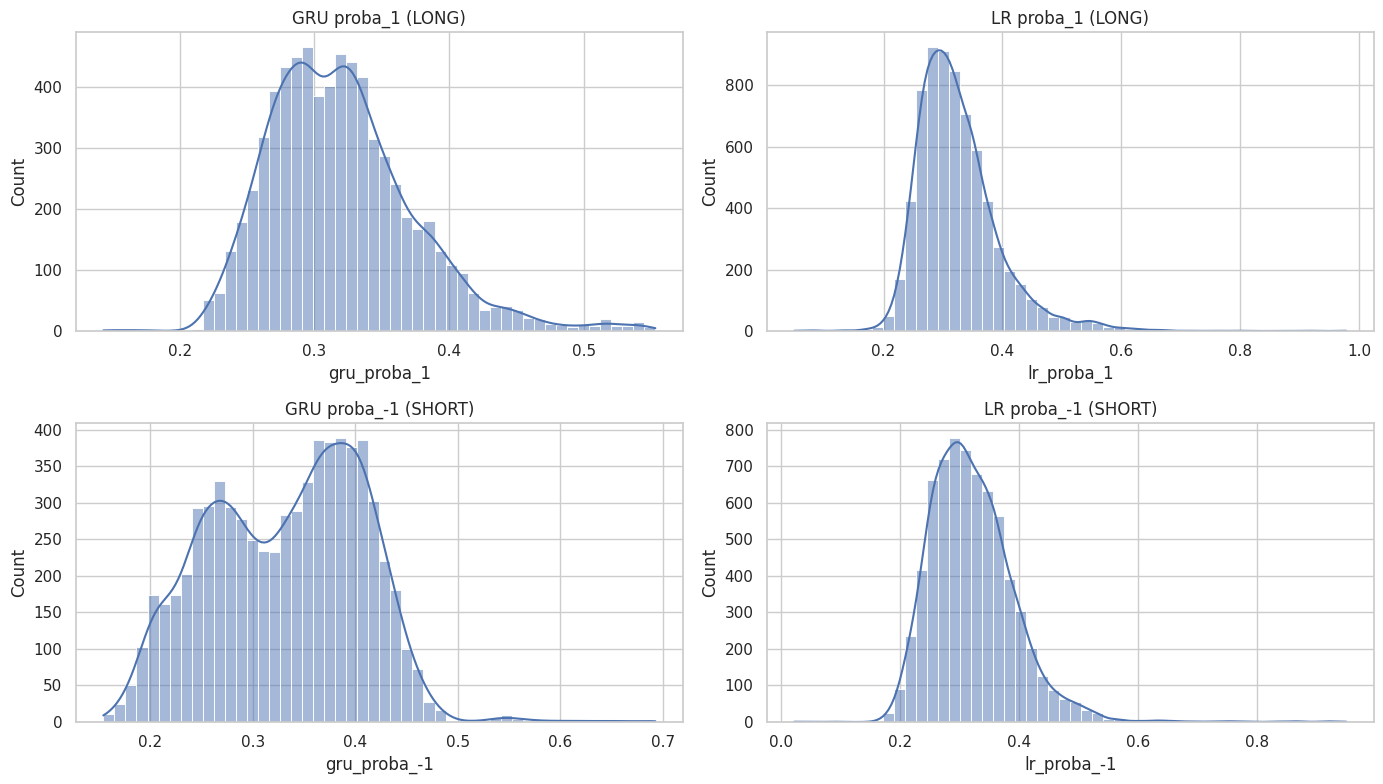

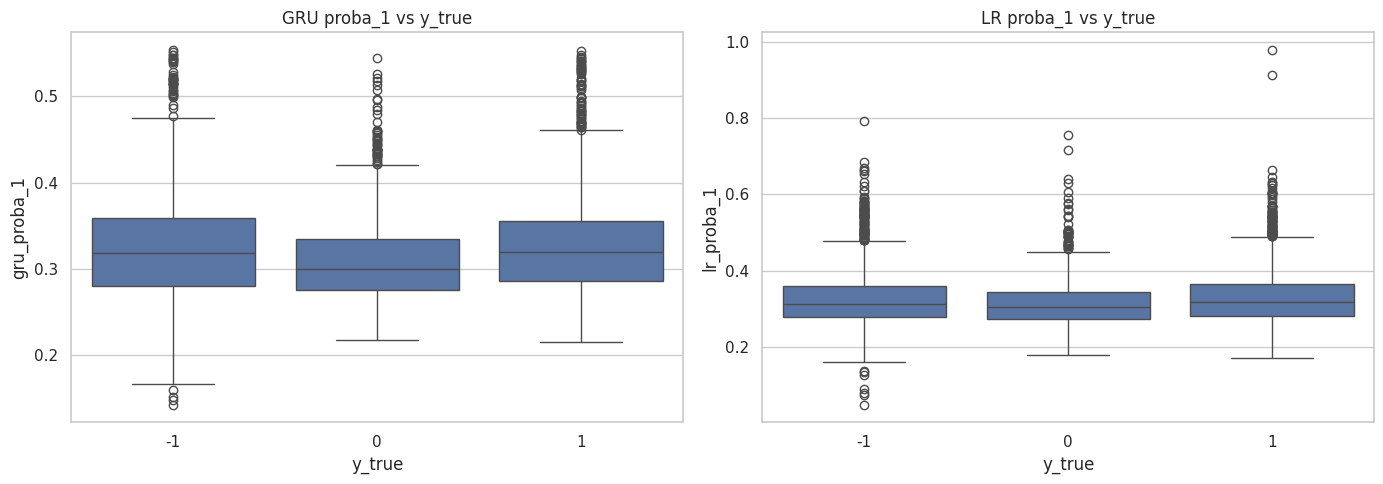

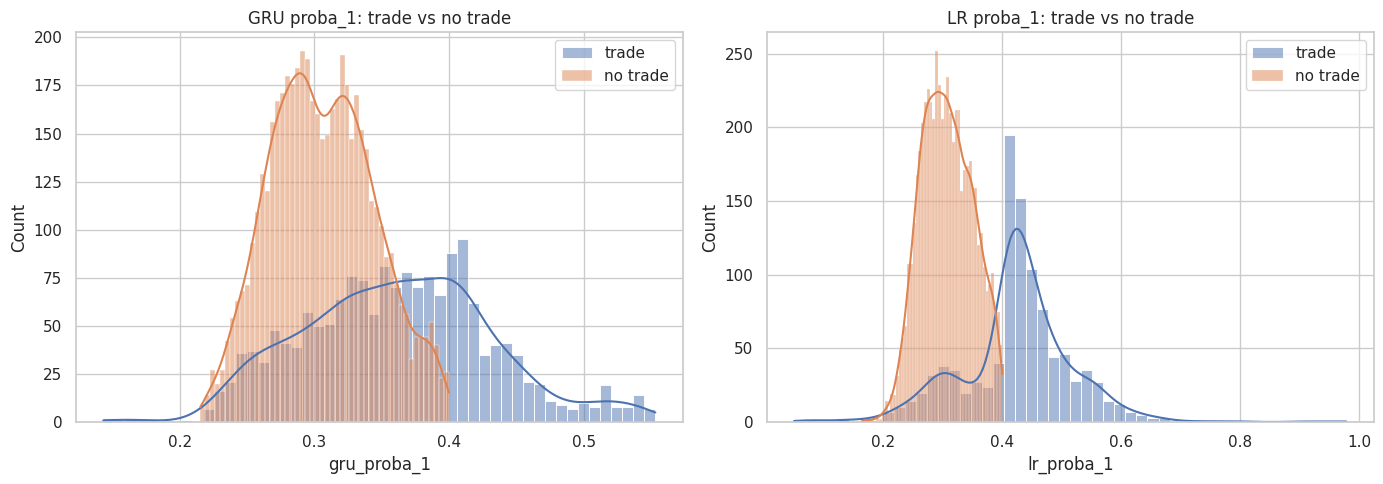

CORRELACIÓN ENTRE MODELOS
Corr LONG  (proba_1):  0.5735
Corr SHORT (proba_-1): 0.7086


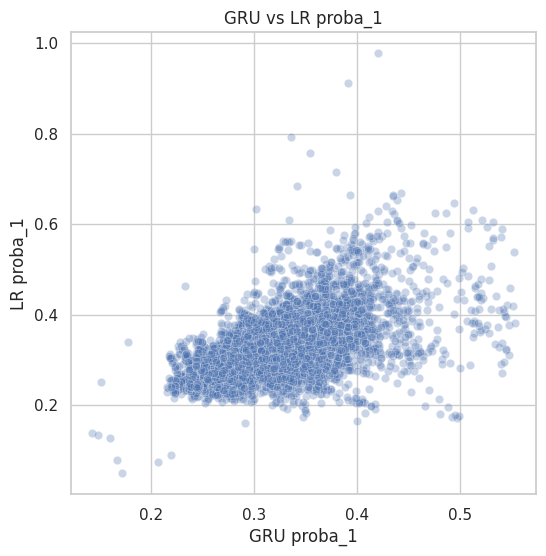

CONFIDENCE OPERATIVA
GRU confidence - trades:


,gru_confidence
count,1691.000000
mean,0.435699
std,0.036759
min,0.400008
25%,0.411660
50%,0.426145
75%,0.445917
max,0.692711


LR confidence - trades:


,lr_confidence
count,1037.000000
mean,0.479593
std,0.075674
min,0.400103
25%,0.428039
50%,0.464123
75%,0.505109
max,0.978255


GRU - PRECISIÓN POR CONFIDENCE BIN


/tmp/ipykernel_4234/2058567854.py:164: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({
/tmp/ipykernel_4234/2058567854.py:174: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


,gru_conf_bin,n_trades,precision
0,"(0.3, 0.35]",0.0,NaN
1,"(0.35, 0.4]",0.0,NaN
2,"(0.4, 0.45]",1327.0,0.453655
3,"(0.45, 0.5]",257.0,0.443580
4,"(0.5, 0.6]",94.0,0.393617
5,"(0.6, 1.0]",13.0,1.000000


LR - PRECISIÓN POR CONFIDENCE BIN


,lr_conf_bin,n_trades,precision
0,"(0.3, 0.35]",0.0,NaN
1,"(0.35, 0.4]",0.0,NaN
2,"(0.4, 0.45]",416.0,0.483173
3,"(0.45, 0.5]",334.0,0.500000
4,"(0.5, 0.6]",227.0,0.396476
5,"(0.6, 1.0]",60.0,0.566667


In [14]:
# =========================================================
# 7. Análisis de probabilidades GRU vs LR
# =========================================================

print("=" * 80)
print("ANÁLISIS DE DISTRIBUCIÓN DE PROBABILIDADES")
print("=" * 80)


# =========================================================
# 7.1. Histogramas de probabilidades long y short
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(df_valid_cmp["gru_proba_1"], bins=50, ax=axes[0, 0], kde=True)
axes[0, 0].set_title("GRU proba_1 (LONG)")

sns.histplot(df_valid_cmp["lr_proba_1"], bins=50, ax=axes[0, 1], kde=True)
axes[0, 1].set_title("LR proba_1 (LONG)")

sns.histplot(df_valid_cmp["gru_proba_-1"], bins=50, ax=axes[1, 0], kde=True)
axes[1, 0].set_title("GRU proba_-1 (SHORT)")

sns.histplot(df_valid_cmp["lr_proba_-1"], bins=50, ax=axes[1, 1], kde=True)
axes[1, 1].set_title("LR proba_-1 (SHORT)")

plt.tight_layout()
plt.show()


# =========================================================
# 7.2. Probabilidades vs clase real
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_valid_cmp, x="y_true", y="gru_proba_1", ax=axes[0])
axes[0].set_title("GRU proba_1 vs y_true")

sns.boxplot(data=df_valid_cmp, x="y_true", y="lr_proba_1", ax=axes[1])
axes[1].set_title("LR proba_1 vs y_true")

plt.tight_layout()
plt.show()


# =========================================================
# 7.3. Probabilidades en trades vs no trades
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df_valid_cmp[df_valid_cmp["gru_trade"]]["gru_proba_1"],
    bins=50,
    label="trade",
    ax=axes[0],
    kde=True
)

sns.histplot(
    df_valid_cmp[~df_valid_cmp["gru_trade"]]["gru_proba_1"],
    bins=50,
    label="no trade",
    ax=axes[0],
    kde=True
)

axes[0].legend()
axes[0].set_title("GRU proba_1: trade vs no trade")

sns.histplot(
    df_valid_cmp[df_valid_cmp["lr_trade"]]["lr_proba_1"],
    bins=50,
    label="trade",
    ax=axes[1],
    kde=True
)

sns.histplot(
    df_valid_cmp[~df_valid_cmp["lr_trade"]]["lr_proba_1"],
    bins=50,
    label="no trade",
    ax=axes[1],
    kde=True
)

axes[1].legend()
axes[1].set_title("LR proba_1: trade vs no trade")

plt.tight_layout()
plt.show()


# =========================================================
# 7.4. Correlación entre modelos
# =========================================================

corr_long = np.corrcoef(
    df_valid_cmp["gru_proba_1"],
    df_valid_cmp["lr_proba_1"]
)[0, 1]

corr_short = np.corrcoef(
    df_valid_cmp["gru_proba_-1"],
    df_valid_cmp["lr_proba_-1"]
)[0, 1]

print("=" * 80)
print("CORRELACIÓN ENTRE MODELOS")
print("=" * 80)
print(f"Corr LONG  (proba_1):  {corr_long:.4f}")
print(f"Corr SHORT (proba_-1): {corr_short:.4f}")


# =========================================================
# 7.5. Scatter plot GRU vs LR
# =========================================================

plt.figure(figsize=(6, 6))

sns.scatterplot(
    x=df_valid_cmp["gru_proba_1"],
    y=df_valid_cmp["lr_proba_1"],
    alpha=0.3
)

plt.title("GRU vs LR proba_1")
plt.xlabel("GRU proba_1")
plt.ylabel("LR proba_1")
plt.show()

# =========================================================
# 7.6. Confidence operativa por modelo
# =========================================================

df_valid_cmp["gru_confidence"] = df_valid_cmp[["gru_proba_-1", "gru_proba_1"]].max(axis=1)
df_valid_cmp["lr_confidence"]  = df_valid_cmp[["lr_proba_-1", "lr_proba_1"]].max(axis=1)

print("=" * 80)
print("CONFIDENCE OPERATIVA")
print("=" * 80)

print("GRU confidence - trades:")
display(df_valid_cmp[df_valid_cmp["gru_trade"]]["gru_confidence"].describe())

print("LR confidence - trades:")
display(df_valid_cmp[df_valid_cmp["lr_trade"]]["lr_confidence"].describe())


# =========================================================
# 7.7. Precisión por bins de confidence
# =========================================================

bins = [0.30, 0.35, 0.40, 0.45, 0.50, 0.60, 1.00]

df_valid_cmp["gru_conf_bin"] = pd.cut(df_valid_cmp["gru_confidence"], bins=bins)
df_valid_cmp["lr_conf_bin"]  = pd.cut(df_valid_cmp["lr_confidence"], bins=bins)

df_gru_conf = (
    df_valid_cmp[df_valid_cmp["gru_trade"]]
    .groupby("gru_conf_bin")
    .apply(lambda x: pd.Series({
        "n_trades": len(x),
        "precision": (x["gru_pred_label"] == x["y_true"]).mean()
    }))
    .reset_index()
)

df_lr_conf = (
    df_valid_cmp[df_valid_cmp["lr_trade"]]
    .groupby("lr_conf_bin")
    .apply(lambda x: pd.Series({
        "n_trades": len(x),
        "precision": (x["lr_pred_label"] == x["y_true"]).mean()
    }))
    .reset_index()
)

print("=" * 80)
print("GRU - PRECISIÓN POR CONFIDENCE BIN")
print("=" * 80)
display(df_gru_conf)

print("=" * 80)
print("LR - PRECISIÓN POR CONFIDENCE BIN")
print("=" * 80)
display(df_lr_conf)

* Las distribuciones de probabilidades muestran que GRU genera valores más concentrados y acotados, mientras que Logistic Regression presenta una mayor dispersión y alcanza niveles de probabilidad más extremos. Esto indica que LR produce señales con mayor rango de confianza, mientras que GRU es más conservador en sus estimaciones.

* En la relación entre probabilidades y clase real, ambos modelos muestran cierta capacidad de separación, aunque no muy marcada. Esto sugiere que la señal predictiva existe, pero es débil, lo que es consistente con el nivel de precisión observado anteriormente.

* Al analizar trade vs no trade, se observa que en ambos modelos las decisiones de operar se concentran en regiones de mayor probabilidad. Sin embargo, esta separación es más clara en LR, lo que confirma que sus reglas de decisión están más alineadas con niveles de confianza altos.

* La correlación entre modelos es moderada-alta (0.57 en long y 0.70 en short), lo que indica que comparten una parte relevante de la señal, pero aún mantienen cierto grado de independencia. Esto refuerza la idea de complementariedad entre ambos modelos.

* En términos de confidence operativa, LR presenta una media significativamente mayor y una mayor dispersión, lo que indica que es capaz de identificar escenarios con mayor convicción. GRU, en cambio, opera en un rango más estrecho de probabilidades.

* El análisis por bins de confidence muestra que en GRU no existe una relación clara entre mayor probabilidad y mayor precisión. Incluso se observa una degradación en los bins superiores, lo que sugiere que su confianza no está bien calibrada.

* En LR, aunque la relación tampoco es estrictamente monótona, se observa un mejor comportamiento en los rangos medios de probabilidad (0.40–0.50), donde alcanza su mejor precisión. En niveles más altos, la precisión vuelve a deteriorarse, lo que indica presencia de sobreconfianza en algunos casos.

* En conjunto, estos resultados sugieren que las probabilidades no pueden utilizarse de forma directa como medida de calidad de señal, especialmente en GRU. Sin embargo, en LR sí existe cierta estructura que podría explotarse mediante filtros adecuados.

* Esto implica que el uso de thresholds fijos puede no ser óptimo, y que será necesario evaluar reglas de decisión más robustas, especialmente si se busca controlar drawdown bajo condiciones de fondeo.

# **8. Construcción y comparación de estrategias sobre VALID**

En este paso se construyen distintas reglas de decisión para transformar las probabilidades de los modelos en señales operativas.

Se comparan estrategias individuales y estrategias combinadas entre GRU y Logistic Regression, manteniendo el análisis sobre el split VALID OOS.

El objetivo es evaluar qué esquema convierte mejor las probabilidades en decisiones de trading, considerando actividad, precisión condicional y proporción total de señales útiles.

En esta etapa la comparación sigue siendo previa al análisis económico completo. Por lo tanto, todavía no se evalúan PnL, equity curve ni drawdown, sino la calidad de las señales antes de someterlas a reglas de fondeo.

In [15]:
# =========================================================
# 8. Construcción y comparación de estrategias sobre VALID
# =========================================================

# Copia de trabajo para construir señales de estrategia
df_strat = df_valid_cmp.copy()


# =========================================================
# 8.1. Función auxiliar para evaluar una estrategia
# =========================================================

def evaluate_strategy(df, signal_col, name):
    """
    Evalúa una estrategia basada en una señal operativa:
        1  = long
       -1  = short
        0  = no trade
    """

    signal = df[signal_col]
    y_true = df["y_true"]

    trade_mask = signal != 0
    n_obs = len(df)
    n_trades = trade_mask.sum()

    if n_trades == 0:
        n_useful = 0
        precision_useful = np.nan
    else:
        n_useful = (signal[trade_mask] == y_true[trade_mask]).sum()
        precision_useful = n_useful / n_trades

    trade_rate = n_trades / n_obs
    useful_rate_total = n_useful / n_obs

    return {
        "strategy": name,
        "n_obs": n_obs,
        "n_trades": n_trades,
        "trade_rate": trade_rate,
        "n_useful": n_useful,
        "precision_useful": precision_useful,
        "useful_rate_total": useful_rate_total,
    }


# =========================================================
# 8.2. Estrategia 1: GRU baseline
# =========================================================

# Usa directamente la señal generada por el modelo GRU
df_strat["signal_gru_baseline"] = df_strat["gru_signal_raw"]


# =========================================================
# 8.3. Estrategia 2: Logistic Regression baseline
# =========================================================

# Usa directamente la señal generada por Logistic Regression
df_strat["signal_lr_baseline"] = df_strat["lr_signal_raw"]


# =========================================================
# 8.4. Estrategia 3: Ensemble por promedio simple
# =========================================================

# Promedio de probabilidades long y short entre GRU y LR
df_strat["ens_score_long"] = (
    df_strat["gru_proba_1"] + df_strat["lr_proba_1"]
) / 2

df_strat["ens_score_short"] = (
    df_strat["gru_proba_-1"] + df_strat["lr_proba_-1"]
) / 2

# Umbrales iniciales del ensemble
thr_ens_long = 0.40
thr_ens_short = 0.40

# Señal inicial: 0 = no trade
df_strat["signal_ensemble_avg"] = 0

# Señal long
df_strat.loc[
    df_strat["ens_score_long"] >= thr_ens_long,
    "signal_ensemble_avg"
] = 1

# Señal short
df_strat.loc[
    df_strat["ens_score_short"] >= thr_ens_short,
    "signal_ensemble_avg"
] = -1

# Resolución de conflictos:
# si long y short superan threshold, se elige el score mayor
conflict_mask = (
    (df_strat["ens_score_long"] >= thr_ens_long) &
    (df_strat["ens_score_short"] >= thr_ens_short)
)

df_strat.loc[
    conflict_mask & (df_strat["ens_score_long"] > df_strat["ens_score_short"]),
    "signal_ensemble_avg"
] = 1

df_strat.loc[
    conflict_mask & (df_strat["ens_score_short"] > df_strat["ens_score_long"]),
    "signal_ensemble_avg"
] = -1

df_strat.loc[
    conflict_mask & (df_strat["ens_score_long"] == df_strat["ens_score_short"]),
    "signal_ensemble_avg"
] = 0


# =========================================================
# 8.5. Estrategia 4: LR dominante + GRU complemento
# =========================================================

# Idea:
# - LR decide cuando tiene alta confianza.
# - Si LR no genera señal, GRU puede aportar una señal secundaria.
# - Se evita operar con GRU si LR contradice claramente la dirección.

thr_lr_long_main = 0.45
thr_lr_short_main = 0.45

thr_gru_long_secondary = 0.42
thr_gru_short_secondary = 0.42

# Señal inicial: 0 = no trade
df_strat["signal_lr_gru_hybrid"] = 0

# Señal principal por LR
df_strat.loc[
    df_strat["lr_proba_1"] >= thr_lr_long_main,
    "signal_lr_gru_hybrid"
] = 1

df_strat.loc[
    df_strat["lr_proba_-1"] >= thr_lr_short_main,
    "signal_lr_gru_hybrid"
] = -1

# GRU actúa solo si LR no decidió
no_signal_mask = df_strat["signal_lr_gru_hybrid"] == 0

# Señal long secundaria por GRU
df_strat.loc[
    no_signal_mask &
    (df_strat["gru_proba_1"] >= thr_gru_long_secondary) &
    (df_strat["lr_proba_-1"] < thr_lr_short_main),
    "signal_lr_gru_hybrid"
] = 1

# Señal short secundaria por GRU
df_strat.loc[
    no_signal_mask &
    (df_strat["gru_proba_-1"] >= thr_gru_short_secondary) &
    (df_strat["lr_proba_1"] < thr_lr_long_main),
    "signal_lr_gru_hybrid"
] = -1


# =========================================================
# 8.6. Evaluación comparativa de estrategias
# =========================================================

strategy_cols = {
    "GRU baseline": "signal_gru_baseline",
    "LR baseline": "signal_lr_baseline",
    "Ensemble avg": "signal_ensemble_avg",
    "LR dominant + GRU": "signal_lr_gru_hybrid",
}

results = []

for strategy_name, signal_col in strategy_cols.items():
    results.append(
        evaluate_strategy(
            df=df_strat,
            signal_col=signal_col,
            name=strategy_name,
        )
    )

df_strategy_results = pd.DataFrame(results)

df_strategy_results = df_strategy_results.sort_values(
    by=["precision_useful", "useful_rate_total"],
    ascending=False
).reset_index(drop=True)

print("=" * 80)
print("COMPARACIÓN DE ESTRATEGIAS - VALID OOS")
print("=" * 80)

display(df_strategy_results)

COMPARACIÓN DE ESTRATEGIAS - VALID OOS


,strategy,n_obs,n_trades,trade_rate,n_useful,precision_useful,useful_rate_total
0,LR baseline,6882,1037,0.150683,493,0.475410,0.071636
1,Ensemble avg,6882,1303,0.189334,612,0.469685,0.088928
2,GRU baseline,6882,1691,0.245713,783,0.463040,0.113775
3,LR dominant + GRU,6882,1221,0.177419,559,0.457821,0.081226


**Observaciones**

* GRU presenta la mayor tasa de operación (0.2457), lo que implica mayor cobertura de oportunidades, pero también mayor exposición al riesgo.
* Logistic Regression muestra la mayor precisión condicional (0.4754), con un perfil más conservador y menor actividad.
* El ensemble logra un equilibrio entre volumen y precisión, pero no supera al GRU en términos de utilidad total.
* La estrategia híbrida (LR dominante + GRU) no aporta mejoras claras y queda por debajo de las alternativas más simples.

---

**Diagnóstico**

1. Dominancia del GRU en términos operativos

* GRU maximiza `useful_rate_total`, que es la métrica más representativa en esta etapa.
* A pesar de menor precisión, compensa con mayor volumen de señales útiles.

Esto indica que el modelo captura más oportunidades, pero con mayor exposición a errores, lo que puede traducirse en mayor drawdown.

---

2. Rol de Logistic Regression

* LR actúa como un modelo más selectivo, con mayor precisión pero menor frecuencia de operación.
* Su aporte principal es la calidad de señal, no la cobertura.

Esto lo posiciona como posible filtro, más que como motor principal de la estrategia.

---

3. Limitaciones del ensemble

* El promedio de probabilidades mejora marginalmente la precisión respecto a GRU.
* Sin embargo, reduce la cantidad de operaciones, afectando negativamente la utilidad total.

No se observa una mejora estructural en el balance entre volumen y calidad.

---

4. Estrategia híbrida

* No logra capturar ventajas claras de ninguno de los dos modelos.
* Pierde en volumen frente a GRU y en precisión frente a LR.

Se puede descartar como configuración principal.

---

**Conclusión**

* GRU baseline constituye la mejor base operativa bajo las reglas actuales de decisión.
* Las combinaciones evaluadas no logran mejorar simultáneamente volumen y calidad de señal.

---

Interpretación

* La señal del GRU es válida, pero se concentra en rangos de probabilidad medios.
* El problema no está en la capacidad predictiva del modelo, sino en la forma en que se transforman esas probabilidades en decisiones operativas.

---

**Siguiente paso**

* No es necesario profundizar en combinaciones entre modelos en esta etapa.
* El foco debe desplazarse hacia la calibración de thresholds del GRU.

Se propone:

* realizar un barrido sistemático de thresholds
* analizar el trade-off entre:
  - volumen de operaciones
  - precisión condicional
  - utilidad total
  - exposición al riesgo (clave para fondeo)

---

**Conclusión final**

El problema no es el modelo, sino la función de decisión y su impacto en el perfil de riesgo.

Este punto es crítico, ya que en el contexto de fondeo no alcanza con maximizar utilidad, sino que es necesario controlar la trayectoria del equity y el drawdown.

# **9. Barrido de theresholds para GRU baseline**

En este paso se realiza un barrido sistemático de thresholds sobre las probabilidades del modelo GRU, considerado como motor principal de señales.

El objetivo es analizar cómo cambian las decisiones operativas al modificar los umbrales de entrada para posiciones long y short.

Para cada combinación de thresholds se evalúan:

- cantidad de trades
- trade_rate
- precisión condicional
- cantidad de señales útiles
- useful_rate_total

Este análisis permite estudiar el trade-off entre volumen y calidad de señal. En el contexto de fondeo, este punto es especialmente importante porque una mayor cantidad de operaciones puede aumentar el PnL potencial, pero también incrementar la exposición al drawdown.

La finalidad no es seleccionar únicamente la configuración con mayor precisión, sino identificar una zona operativa razonable que combine actividad suficiente, calidad de señal y menor exposición al riesgo.

BARRIDO DE THRESHOLDS - GRU BASELINE


,strategy,n_obs,n_trades,trade_rate,n_useful,precision_useful,useful_rate_total,threshold_long,threshold_short
0,GRU threshold grid,6882,5321,0.773176,2226,0.418342,0.323452,0.30,0.30
1,GRU threshold grid,6882,5258,0.764022,2208,0.419932,0.320837,0.30,0.31
2,GRU threshold grid,6882,5057,0.734815,2195,0.434052,0.318948,0.30,0.34
3,GRU threshold grid,6882,5134,0.746004,2195,0.427542,0.318948,0.30,0.33
4,GRU threshold grid,6882,5198,0.755304,2190,0.421316,0.318221,0.30,0.32
5,GRU threshold grid,6882,4971,0.722319,2164,0.435325,0.314443,0.30,0.35
6,GRU threshold grid,6882,4884,0.709677,2127,0.435504,0.309067,0.30,0.36
7,GRU threshold grid,6882,5086,0.739029,2124,0.417617,0.308631,0.31,0.30
8,GRU threshold grid,6882,4999,0.726388,2098,0.419684,0.304853,0.31,0.31
9,GRU threshold grid,6882,4844,0.703865,2075,0.428365,0.301511,0.31,0.33


TOP CONFIGURACIONES CON trade_rate >= 0.05


,strategy,n_obs,n_trades,trade_rate,n_useful,precision_useful,useful_rate_total,threshold_long,threshold_short
0,GRU threshold grid,6882,420,0.061029,224,0.533333,0.032549,0.41,0.56
1,GRU threshold grid,6882,432,0.062772,230,0.532407,0.033421,0.41,0.54
2,GRU threshold grid,6882,423,0.061465,225,0.531915,0.032694,0.41,0.55
3,GRU threshold grid,6882,435,0.063208,229,0.526437,0.033275,0.41,0.53
4,GRU threshold grid,6882,436,0.063354,229,0.525229,0.033275,0.41,0.52
5,GRU threshold grid,6882,437,0.063499,229,0.524027,0.033275,0.41,0.50
6,GRU threshold grid,6882,437,0.063499,229,0.524027,0.033275,0.41,0.51
7,GRU threshold grid,6882,438,0.063644,228,0.520548,0.033130,0.41,0.49
8,GRU threshold grid,6882,346,0.050276,179,0.517341,0.026010,0.42,0.49
9,GRU threshold grid,6882,449,0.065243,231,0.514477,0.033566,0.41,0.48


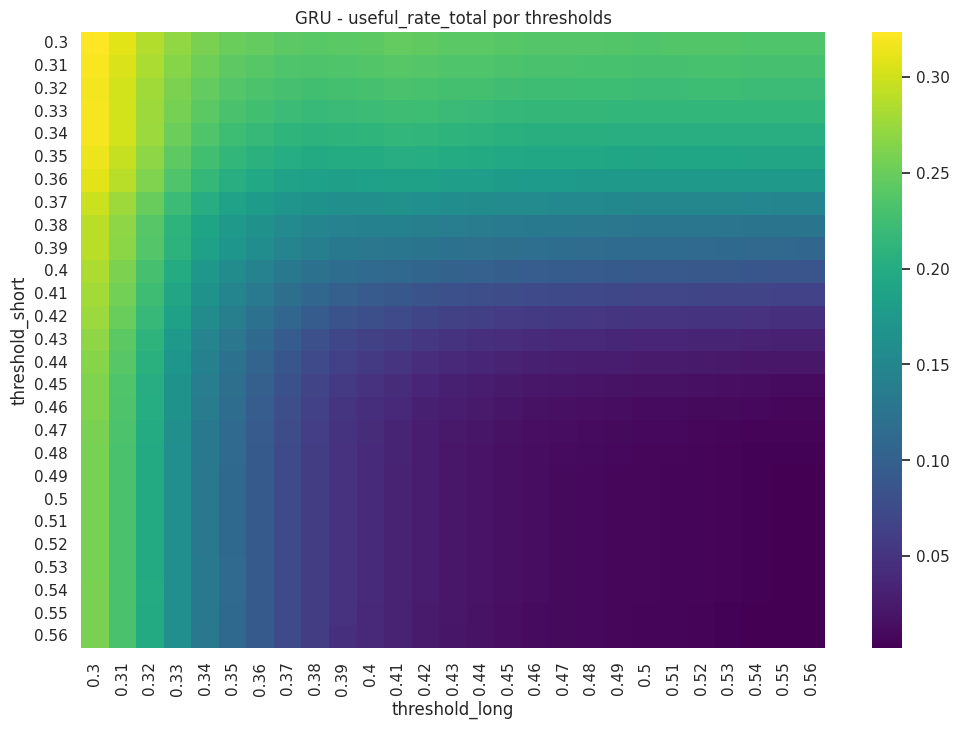

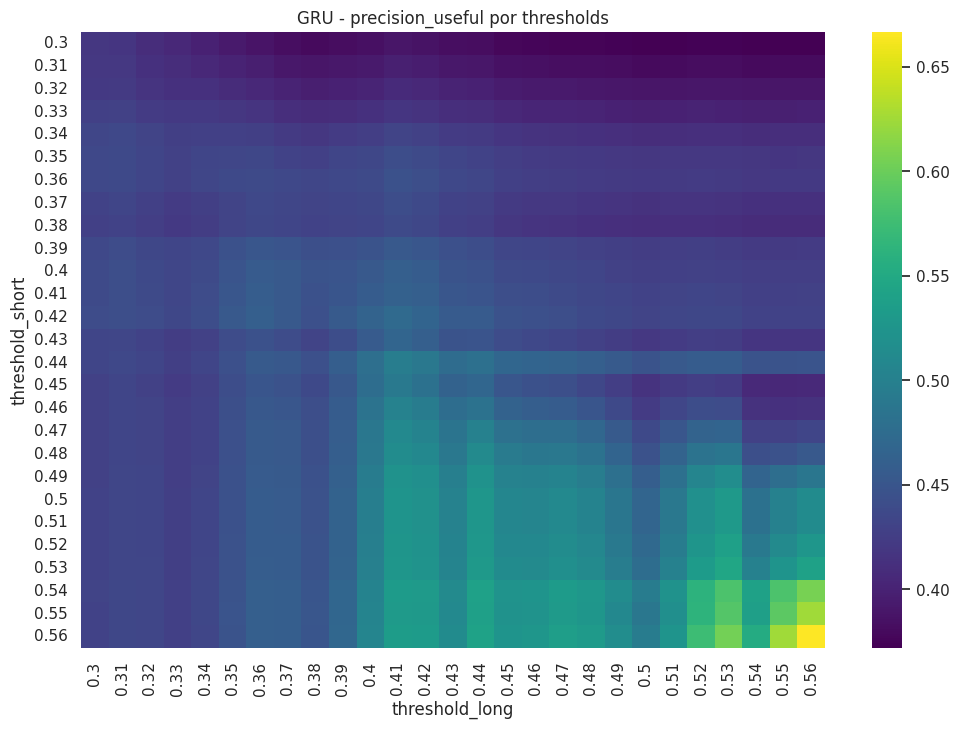

CONFIGURACIONES CANDIDATAS - GRU


,strategy,n_obs,n_trades,trade_rate,n_useful,precision_useful,useful_rate_total,threshold_long,threshold_short
0,GRU threshold grid,6882,5321,0.773176,2226,0.418342,0.323452,0.30,0.30
1,GRU threshold grid,6882,420,0.061029,224,0.533333,0.032549,0.41,0.56


In [16]:
# =========================================================
# 9. Barrido de thresholds para GRU baseline
# =========================================================

df_gru_thr = df_strat.copy()


# =========================================================
# 9.1. Función para generar señales con thresholds variables
# =========================================================

def build_signal_from_thresholds(
    df: pd.DataFrame,
    proba_long_col: str,
    proba_short_col: str,
    threshold_long: float,
    threshold_short: float,
) -> np.ndarray:
    """
    Genera señales operativas:
        1  = long
       -1  = short
        0  = no trade

    Si long y short superan threshold al mismo tiempo,
    se elige la dirección con mayor probabilidad.
    """

    p_long = df[proba_long_col].values
    p_short = df[proba_short_col].values

    long_mask = p_long >= threshold_long
    short_mask = p_short >= threshold_short

    signal = np.zeros(len(df), dtype=int)

    # Casos sin conflicto
    signal[long_mask & ~short_mask] = 1
    signal[short_mask & ~long_mask] = -1

    # Casos con conflicto
    conflict_mask = long_mask & short_mask

    signal[conflict_mask & (p_long > p_short)] = 1
    signal[conflict_mask & (p_short > p_long)] = -1
    signal[conflict_mask & (p_long == p_short)] = 0

    return signal


# =========================================================
# 9.2. Definición del grid de thresholds
# =========================================================

# Rango de thresholds a evaluar para long y short
threshold_values = np.round(np.arange(0.30, 0.56, 0.01), 2)

results_thr = []

for thr_long in threshold_values:
    for thr_short in threshold_values:

        # Generar señal GRU usando la combinación actual de thresholds
        signal = build_signal_from_thresholds(
            df=df_gru_thr,
            proba_long_col="gru_proba_1",
            proba_short_col="gru_proba_-1",
            threshold_long=thr_long,
            threshold_short=thr_short,
        )

        # Copia temporal para evaluar la estrategia
        tmp = df_gru_thr.copy()
        tmp["signal_gru_thr"] = signal

        # Evaluar métricas operativas
        metrics = evaluate_strategy(
            df=tmp,
            signal_col="signal_gru_thr",
            name="GRU threshold grid",
        )

        # Registrar thresholds evaluados
        metrics["threshold_long"] = thr_long
        metrics["threshold_short"] = thr_short

        results_thr.append(metrics)


# Consolidar resultados del barrido
df_gru_threshold_grid = pd.DataFrame(results_thr)


# =========================================================
# 9.3. Ranking por useful_rate_total
# =========================================================

df_gru_threshold_grid = df_gru_threshold_grid.sort_values(
    by=["useful_rate_total", "precision_useful", "trade_rate"],
    ascending=False
).reset_index(drop=True)

print("=" * 80)
print("BARRIDO DE THRESHOLDS - GRU BASELINE")
print("=" * 80)

display(df_gru_threshold_grid.head(20))


# =========================================================
# 9.4. Ranking con filtro operativo mínimo
# =========================================================

# Filtro mínimo para evitar configuraciones con muy baja actividad
min_trade_rate = 0.05

df_gru_threshold_filtered = df_gru_threshold_grid[
    df_gru_threshold_grid["trade_rate"] >= min_trade_rate
].copy()

df_gru_threshold_filtered = df_gru_threshold_filtered.sort_values(
    by=["precision_useful", "useful_rate_total"],
    ascending=False
).reset_index(drop=True)

print("=" * 80)
print(f"TOP CONFIGURACIONES CON trade_rate >= {min_trade_rate}")
print("=" * 80)

display(df_gru_threshold_filtered.head(20))


# =========================================================
# 9.5. Heatmap de useful_rate_total
# =========================================================

heatmap_useful = df_gru_threshold_grid.pivot_table(
    index="threshold_short",
    columns="threshold_long",
    values="useful_rate_total",
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    heatmap_useful,
    cmap="viridis",
    annot=False
)

plt.title("GRU - useful_rate_total por thresholds")
plt.xlabel("threshold_long")
plt.ylabel("threshold_short")
plt.show()


# =========================================================
# 9.6. Heatmap de precision_useful
# =========================================================

heatmap_precision = df_gru_threshold_grid.pivot_table(
    index="threshold_short",
    columns="threshold_long",
    values="precision_useful",
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    heatmap_precision,
    cmap="viridis",
    annot=False
)

plt.title("GRU - precision_useful por thresholds")
plt.xlabel("threshold_long")
plt.ylabel("threshold_short")
plt.show()

# =========================================================
# 9.7. Selección preliminar de configuraciones candidatas
# =========================================================

print("=" * 80)
print("CONFIGURACIONES CANDIDATAS - GRU")
print("=" * 80)

# Candidata 1: máxima utilidad total
best_useful = df_gru_threshold_grid.iloc[0]

# Candidata 2: mayor precisión con actividad mínima
best_precision_filtered = df_gru_threshold_filtered.iloc[0]

df_gru_candidates = pd.DataFrame([
    best_useful,
    best_precision_filtered,
]).drop_duplicates().reset_index(drop=True)

display(df_gru_candidates)

print("=" * 80)

## **Observaciones generales**


Cuando los thresholds son bajos (≈ 0.30):

* el modelo opera en una gran proporción de las observaciones (~70–77%)
* el `useful_rate_total` alcanza sus valores máximos (~0.32)
* la precisión se mantiene en niveles bajos (~0.41–0.43)

Esto indica que el modelo genera muchas oportunidades, pero con alto nivel de ruido y, por lo tanto, mayor exposición al drawdown.

---

A medida que aumentan los thresholds:

* el número de trades disminuye de forma significativa
* la precisión mejora progresivamente

Se observa un comportamiento más selectivo, donde el modelo filtra mejor las señales, pero a costa de perder volumen operativo.

---

En thresholds altos (≥ 0.50):

* la precisión supera el 0.50
* la tasa de operación cae a niveles muy bajos (~5–8%)
* el `useful_rate_total` disminuye fuertemente (~0.03–0.04)

Esto refleja un régimen excesivamente conservador, donde la estrategia deja de capturar la mayor parte del edge disponible.

---

Lectura del heatmap

* El máximo de `useful_rate_total` se concentra claramente en la zona de thresholds bajos (0.30–0.33).
* La máxima precisión aparece en la zona de thresholds altos (0.50–0.56).
* No existe una región donde ambas métricas sean simultáneamente altas.

Esto confirma un trade-off estructural entre volumen y calidad de señal.

---

Insight principal

El modelo GRU sí contiene señal predictiva, pero esta no se manifiesta en probabilidades extremas.

La mayor parte del valor está en rangos intermedios, por lo que:

* thresholds altos eliminan gran parte del edge
* thresholds bajos capturan el edge, pero con mayor ruido

---

Zona operativamente relevante

Los resultados sugieren una zona intermedia más estable:

* `threshold_long ≈ 0.40–0.42`
* `threshold_short ≈ 0.45–0.55`

En esta región se obtiene:

* precisión cercana o superior a 0.50
* `trade_rate` entre 0.06 y 0.08
* menor exposición al ruido respecto al baseline agresivo

---

Interpretación clave (muy importante)

El mejor `useful_rate_total` no implica mejor estrategia bajo condiciones reales.

Configuraciones como (0.30 / 0.30):

* maximizan utilidad en papel
* pero implican una actividad extremadamente alta (~77%)

Esto, en un entorno de fondeo, probablemente genere:

* alta volatilidad de la equity
* mayor probabilidad de alcanzar límites de drawdown

---

Conclusión

* thresholds bajos maximizan utilidad, pero aumentan el riesgo
* thresholds altos mejoran la precisión, pero destruyen el edge
* la zona intermedia ofrece un mejor balance entre señal y control

El baseline (0.40 / 0.40) se mantiene como referencia razonable, pero existen configuraciones más conservadoras que podrían ser preferibles bajo restricciones de riesgo.

---

Idea clave

El desempeño del modelo no es el problema principal.

El punto crítico es cómo se traduce la probabilidad en decisiones operativas, ya que esto determina directamente el perfil de riesgo de la estrategia.

---

Siguiente paso

Reducir el espacio de búsqueda a un conjunto de configuraciones candidatas representativas:

* agresiva (alto volumen)
* balanceada
* conservadora (alta precisión)

y evaluarlas en términos de:

* PnL
* equity curve
* drawdown
* supervivencia bajo reglas de fondeo

# **10. Selección y comparación de configuraciones candidatas**

En este paso se selecciona un conjunto reducido de configuraciones de thresholds a partir del barrido previo.

El objetivo es comparar alternativas representativas del trade-off entre volumen, calidad de señal y exposición al riesgo.

Las configuraciones seleccionadas representan distintos perfiles operativos:

* baseline: referencia utilizada hasta el momento
* balanced: menor exposición manteniendo actividad razonable
* conservative: prioriza mayor precisión
* high precision: configuración más restrictiva observada en el grid

Esta comparación no busca definir todavía la estrategia final, sino seleccionar candidatas que luego serán evaluadas mediante PnL, equity curve, drawdown y reglas de fondeo.

In [17]:
# =========================================================
# 10. Selección y comparación de configuraciones candidatas
# =========================================================

# =========================================================
# 10.1. Definición de configuraciones candidatas
# =========================================================

candidate_configs = [
    {
        "strategy": "GRU baseline",
        "profile": "baseline",
        "threshold_long": 0.40,
        "threshold_short": 0.40,
        "description": "Configuración base utilizada hasta el momento",
    },
    {
        "strategy": "GRU balanced",
        "profile": "balanced",
        "threshold_long": 0.40,
        "threshold_short": 0.45,
        "description": "Configuración levemente más conservadora en short",
    },
    {
        "strategy": "GRU conservative",
        "profile": "conservative",
        "threshold_long": 0.41,
        "threshold_short": 0.50,
        "description": "Configuración orientada a mayor precisión",
    },
    {
        "strategy": "GRU high_precision",
        "profile": "high_precision",
        "threshold_long": 0.41,
        "threshold_short": 0.56,
        "description": "Configuración de máxima precisión observada en el grid",
    },
]

# =========================================================
# 10.2. Evaluación de configuraciones candidatas
# =========================================================

candidate_results = []

for config in candidate_configs:

    signal = build_signal_from_thresholds(
        df=df_strat,
        proba_long_col="gru_proba_1",
        proba_short_col="gru_proba_-1",
        threshold_long=config["threshold_long"],
        threshold_short=config["threshold_short"],
    )

    tmp = df_strat.copy()
    tmp["signal_candidate"] = signal

    metrics = evaluate_strategy(
        df=tmp,
        signal_col="signal_candidate",
        name=config["strategy"],
    )

    metrics["profile"] = config["profile"]
    metrics["threshold_long"] = config["threshold_long"]
    metrics["threshold_short"] = config["threshold_short"]
    metrics["description"] = config["description"]

    candidate_results.append(metrics)

df_candidate_results = pd.DataFrame(candidate_results)

# =========================================================
# 10.3. Ordenamiento de resultados
# =========================================================

df_candidate_results = df_candidate_results.sort_values(
    by=["trade_rate"],
    ascending=False
).reset_index(drop=True)

# =========================================================
# 10.4. Visualización de resultados
# =========================================================

print("=" * 80)
print("COMPARACIÓN DE CONFIGURACIONES CANDIDATAS - GRU")
print("=" * 80)

display(df_candidate_results)

COMPARACIÓN DE CONFIGURACIONES CANDIDATAS - GRU


,strategy,n_obs,n_trades,trade_rate,n_useful,precision_useful,useful_rate_total,profile,threshold_long,threshold_short,description
0,GRU baseline,6882,1691,0.245713,766,0.452986,0.111305,baseline,0.40,0.40,Configuración base utilizada hasta el momento
1,GRU balanced,6882,699,0.101569,333,0.476395,0.048387,balanced,0.40,0.45,Configuración levemente más conservadora en short
2,GRU conservative,6882,437,0.063499,229,0.524027,0.033275,conservative,0.41,0.50,Configuración orientada a mayor precisión
3,GRU high_precision,6882,420,0.061029,224,0.533333,0.032549,high_precision,0.41,0.56,Configuración de máxima precisión observada en...


**Observaciones**

* GRU baseline presenta la mayor actividad (trade_rate ~0.25) y el mayor `useful_rate_total` (0.1113), lo que indica máxima captura de oportunidades, pero también mayor exposición al riesgo.
* GRU balanced reduce significativamente la actividad (~0.10), mejora la precisión (~0.476) y mantiene un nivel intermedio de utilidad total, mostrando un mejor equilibrio entre volumen y calidad.
* GRU conservative y high_precision alcanzan las mayores precisiones (>0.52), pero con una actividad muy baja (~0.06), lo que limita fuertemente la generación de señales útiles.
* A medida que aumenta la precisión, la reducción en número de trades es desproporcionada, afectando negativamente el `useful_rate_total`.

---

**Diagnóstico**

* Existe un trade-off estructural entre volumen de operaciones y calidad de señal.
* GRU baseline maximiza utilidad en términos absolutos, pero con un perfil potencialmente riesgoso.
* GRU balanced reduce exposición manteniendo una calidad de señal superior, posicionándose como alternativa más robusta.
* Las configuraciones más conservadoras priorizan precisión, pero sacrifican gran parte del edge del modelo.

---

**Conclusión**

* GRU baseline es la mejor configuración en términos de generación de señales, pero no necesariamente en términos de control de riesgo.
* GRU balanced representa el mejor compromiso entre actividad, precisión y exposición.
* GRU conservative y high_precision quedan como configuraciones de referencia para escenarios donde se prioriza precisión sobre volumen.

---

**Interpretación clave**

* El incremento de precisión no compensa la caída en volumen desde el punto de vista de utilidad total.
* Sin embargo, en un contexto de fondeo, menor volumen puede traducirse en menor volatilidad de la equity y menor drawdown.

---

**Siguiente paso**

* Evaluar estas configuraciones en términos de:
  - PnL
  - equity curve
  - drawdown
  - supervivencia bajo reglas de fondeo

El objetivo es determinar cuál de estos perfiles es viable en condiciones reales, no solo cuál maximiza métricas operativas.


# **11. Validación en TEST OOS**

En este paso se evalúan en TEST OOS las configuraciones candidatas definidas previamente sobre VALID.

El objetivo es verificar si las reglas de decisión mantienen un comportamiento estable fuera del conjunto utilizado para el diseño de la estrategia.

Para evitar sobreajuste, no se modifican thresholds ni reglas en esta etapa. Las configuraciones se aplican exactamente igual que en VALID.

Además, se incorpora la alineación temporal y económica del split TEST, agregando fecha, minuto de operación, precio de cierre y delta_30. Esto permite dejar el dataset preparado para la evaluación posterior de PnL, equity curve, drawdown y reglas de fondeo.

In [18]:
# =========================================================
# 11. Validación en TEST OOS
# =========================================================

print("=" * 80)
print("VALIDACIÓN EN TEST OOS - GRU")
print("=" * 80)

# =========================================================
# 11.1. Selección de datos TEST para GRU
# =========================================================

split_test = "test"
target_col = "t2_p40_h30"
L = 30

df_gru_test = (
    df_prob_oos[
        (df_prob_oos["split"] == split_test) &
        (df_prob_oos["target"] == target_col) &
        (df_prob_oos["model"] == "gru")
    ]
    .reset_index(drop=True)
    .copy()
)

print(f"Shape df_gru_test: {df_gru_test.shape}")


# =========================================================
# 11.2. Reconstrucción de TEST alineado desde dataset T2 completo
# =========================================================

df_base = (
    df_t2_full
    .sort_values(["date", "minute_of_day"])
    .reset_index(drop=True)
    .copy()
)

df_base["_day"] = pd.to_datetime(df_base["date"]).dt.date

unique_days = pd.Index(sorted(df_base["_day"].unique()))

n_days = len(unique_days)
n_train_days = int(n_days * 0.70)
n_valid_days = int(n_days * 0.15)

test_days = set(unique_days[n_train_days + n_valid_days:])

df_test_raw = df_base[df_base["_day"].isin(test_days)].copy()

df_test_aligned = (
    df_test_raw
    .groupby("_day", group_keys=False)
    .apply(lambda x: x.iloc[L - 1:], include_groups=False)
    .reset_index(drop=True)
)

print(f"TEST raw rows    : {len(df_test_raw)}")
print(f"TEST aligned rows: {len(df_test_aligned)}")

assert len(df_gru_test) == len(df_test_aligned), (
    "TEST no alinea en cantidad entre probabilidades y dataset T2."
)

test_match = (
    df_gru_test["y_true"].values == df_test_aligned[target_col].values
).mean()

print(f"Match TEST y_true: {test_match:.4f}")

assert test_match == 1.0, "TEST no alinea perfectamente contra y_true."


# =========================================================
# 11.3. Adaptación de columnas al formato usado en VALID
# =========================================================

df_test_gru_cmp = pd.DataFrame({
    "date": df_test_aligned["date"].values,
    "minute_of_day": df_test_aligned["minute_of_day"].values,
    "close": df_test_aligned["close"].values,
    "delta_30": df_test_aligned["delta_30"].values,

    "y_true": df_gru_test["y_true"].values,
    "gru_proba_-1": df_gru_test["proba_-1"].values,
    "gru_proba_0":  df_gru_test["proba_0"].values,
    "gru_proba_1":  df_gru_test["proba_1"].values,
    "gru_pred_label": df_gru_test["pred_label"].values,
    "gru_signal_raw": df_gru_test["signal_raw"].values,
    "gru_trade": df_gru_test["trade"].values,
})

print("-" * 80)
print("df_test_gru_cmp construido correctamente:")
print(df_test_gru_cmp.shape)


# =========================================================
# 11.4. Evaluación de configuraciones candidatas en TEST
# =========================================================

test_results = []

for config in candidate_configs:

    signal = build_signal_from_thresholds(
        df=df_test_gru_cmp,
        proba_long_col="gru_proba_1",
        proba_short_col="gru_proba_-1",
        threshold_long=config["threshold_long"],
        threshold_short=config["threshold_short"],
    )

    tmp = df_test_gru_cmp.copy()
    tmp["signal_candidate"] = signal

    metrics = evaluate_strategy(
        df=tmp,
        signal_col="signal_candidate",
        name=config["strategy"],
    )

    metrics["split"] = "test"
    metrics["profile"] = config.get("profile", None)
    metrics["threshold_long"] = config["threshold_long"]
    metrics["threshold_short"] = config["threshold_short"]
    metrics["description"] = config["description"]

    test_results.append(metrics)

df_candidate_results_test = pd.DataFrame(test_results)


# =========================================================
# 11.5. Ordenamiento de resultados TEST
# =========================================================

df_candidate_results_test = df_candidate_results_test.sort_values(
    by=["trade_rate"],
    ascending=False
).reset_index(drop=True)

print("=" * 80)
print("VALIDACIÓN TEST OOS - CONFIGURACIONES GRU")
print("=" * 80)

display(df_candidate_results_test)

VALIDACIÓN EN TEST OOS - GRU
Shape df_gru_test: (6913, 18)
TEST raw rows    : 13380
TEST aligned rows: 6913
Match TEST y_true: 1.0000
--------------------------------------------------------------------------------
df_test_gru_cmp construido correctamente:
(6913, 11)
VALIDACIÓN TEST OOS - CONFIGURACIONES GRU


,strategy,n_obs,n_trades,trade_rate,n_useful,precision_useful,useful_rate_total,split,profile,threshold_long,threshold_short,description
0,GRU baseline,6913,916,0.132504,361,0.394105,0.052220,test,baseline,0.40,0.40,Configuración base utilizada hasta el momento
1,GRU balanced,6913,309,0.044698,137,0.443366,0.019818,test,balanced,0.40,0.45,Configuración levemente más conservadora en short
2,GRU conservative,6913,188,0.027195,72,0.382979,0.010415,test,conservative,0.41,0.50,Configuración orientada a mayor precisión
3,GRU high_precision,6913,188,0.027195,72,0.382979,0.010415,test,high_precision,0.41,0.56,Configuración de máxima precisión observada en...


**Observaciones**

* Todas las configuraciones presentan una caída significativa en desempeño al pasar de VALID a TEST, tanto en precisión como en `useful_rate_total`.
* GRU baseline sigue siendo la configuración con mayor actividad y mayor utilidad total, aunque con una reducción notable respecto a VALID.
* GRU balanced mantiene su perfil intermedio, con menor volumen y mejor precisión relativa que baseline, pero también con pérdida de desempeño.
* Las configuraciones conservative y high_precision no logran sostener la alta precisión observada en VALID, cayendo a niveles incluso inferiores al baseline.

---

**Diagnóstico**

* Existe una degradación clara de generalización, lo que indica que parte del comportamiento observado en VALID estaba optimista.
* La relación entre mayor threshold y mayor precisión no se sostiene en TEST.
* Las configuraciones más restrictivas pierden tanto volumen como calidad de señal fuera de muestra.

---

**Insight clave**

* La señal del modelo es débil y sensible a cambios de muestra.
* Aumentar thresholds no garantiza mejor calidad en datos no vistos.
* El aparente “beneficio” de configuraciones conservadoras en VALID era en parte ruido.

---

**Conclusión**

* GRU baseline sigue siendo la configuración más robusta en términos relativos.
* GRU balanced puede considerarse como alternativa más conservadora, pero con menor generación de señales.
* Las configuraciones conservative y high_precision deben descartarse como opciones principales.

---

**Interpretación para fondeo**

* La reducción de trade_rate en TEST implica menor exposición, pero también menor capacidad de generar PnL.
* La caída de precisión en configuraciones conservadoras es especialmente relevante, ya que elimina el principal argumento para usarlas.

---

**Siguiente paso**

* Evaluar GRU baseline y GRU balanced en términos de:
  - PnL
  - equity curve
  - drawdown
  - cumplimiento de reglas de fondeo

El foco pasa de optimizar métricas operativas a validar supervivencia bajo condiciones reales.


# **12. Evaluación operativa de las señales (PnL)**

En este paso se transforma la señal de trading en resultados económicos utilizando directamente las variables ya alineadas en etapas previas.

No es necesario repetir el proceso de alineación temporal, dado que los datasets utilizados ya contienen la información sincronizada entre señales y mercado.

El objetivo es evaluar el desempeño real de las estrategias en términos de PnL, pasando de métricas de clasificación a métricas económicas.

Esto constituye el primer paso hacia la evaluación de la estrategia bajo condiciones reales de trading.


In [19]:
# =========================================================
# 12. Evaluación operativa de las señales (PnL)
# =========================================================

print("=" * 80)
print("EVALUACIÓN OPERATIVA - PnL")
print("=" * 80)

# =========================================================
# 12.1. Función de PnL por trade
# =========================================================

def compute_pnl(df, signal_col):
    """
    Calcula PnL por trade usando delta_30:

    signal:
        1  = long  → gana si delta_30 > 0
       -1  = short → gana si delta_30 < 0
        0  = no trade → 0

    """
    signal = df[signal_col]
    delta = df["delta_30"]

    pnl = signal * delta

    return pnl


# =========================================================
# 12.2. Aplicar a configuraciones candidatas (VALID)
# =========================================================

pnl_results_valid = []

for config in candidate_configs:

    signal = build_signal_from_thresholds(
        df=df_valid_cmp,
        proba_long_col="gru_proba_1",
        proba_short_col="gru_proba_-1",
        threshold_long=config["threshold_long"],
        threshold_short=config["threshold_short"],
    )

    tmp = df_valid_cmp.copy()
    tmp["signal"] = signal

    tmp["pnl"] = compute_pnl(tmp, "signal")

    pnl_results_valid.append({
        "strategy": config["strategy"],
        "profile": config.get("profile"),
        "threshold_long": config["threshold_long"],
        "threshold_short": config["threshold_short"],
        "total_pnl": tmp["pnl"].sum(),
        "mean_pnl": tmp["pnl"].mean(),
        "n_trades": (tmp["signal"] != 0).sum(),
    })

df_pnl_valid = pd.DataFrame(pnl_results_valid)

print("=" * 80)
print("RESULTADOS PnL - VALID")
print("=" * 80)

display(df_pnl_valid)


# =========================================================
# 12.3. Aplicar a TEST
# =========================================================

pnl_results_test = []

for config in candidate_configs:

    signal = build_signal_from_thresholds(
        df=df_test_gru_cmp,
        proba_long_col="gru_proba_1",
        proba_short_col="gru_proba_-1",
        threshold_long=config["threshold_long"],
        threshold_short=config["threshold_short"],
    )

    tmp = df_test_gru_cmp.copy()
    tmp["signal"] = signal

    tmp["pnl"] = compute_pnl(tmp, "signal")

    pnl_results_test.append({
        "strategy": config["strategy"],
        "profile": config.get("profile"),
        "threshold_long": config["threshold_long"],
        "threshold_short": config["threshold_short"],
        "total_pnl": tmp["pnl"].sum(),
        "mean_pnl": tmp["pnl"].mean(),
        "n_trades": (tmp["signal"] != 0).sum(),
    })

df_pnl_test = pd.DataFrame(pnl_results_test)

print("=" * 80)
print("RESULTADOS PnL - TEST")
print("=" * 80)

display(df_pnl_test)

EVALUACIÓN OPERATIVA - PnL
RESULTADOS PnL - VALID


,strategy,profile,threshold_long,threshold_short,total_pnl,mean_pnl,n_trades
0,GRU baseline,baseline,0.40,0.40,17542.75,2.549077,1691
1,GRU balanced,balanced,0.40,0.45,6845.25,0.994660,699
2,GRU conservative,conservative,0.41,0.50,8370.75,1.216325,437
3,GRU high_precision,high_precision,0.41,0.56,10033.50,1.457934,420


RESULTADOS PnL - TEST


,strategy,profile,threshold_long,threshold_short,total_pnl,mean_pnl,n_trades
0,GRU baseline,baseline,0.40,0.40,2266.25,0.327824,916
1,GRU balanced,balanced,0.40,0.45,3916.75,0.566577,309
2,GRU conservative,conservative,0.41,0.50,317.00,0.045856,188
3,GRU high_precision,high_precision,0.41,0.56,317.00,0.045856,188


Observaciones

* En VALID, GRU baseline presenta el mayor PnL total, impulsado principalmente por su alto volumen de operaciones.
* A medida que se incrementan los thresholds, el PnL total disminuye en VALID, pero el PnL promedio por trade aumenta, reflejando mayor calidad de señal.
* GRU high_precision logra el mayor PnL medio en VALID, aunque con menor cantidad de trades.

---

Comportamiento en TEST

* Se observa una degradación significativa del PnL en todas las configuraciones al pasar de VALID a TEST.
* GRU baseline sufre una caída muy fuerte en PnL total, evidenciando alta sensibilidad al cambio de muestra.
* GRU balanced se posiciona como la mejor configuración en TEST, superando al baseline tanto en PnL total como en PnL medio.
* GRU conservative y high_precision prácticamente pierden capacidad de generar PnL, mostrando resultados muy bajos.

---

Diagnóstico

* El alto volumen del baseline no se traduce en robustez fuera de muestra.
* La mejora de precisión en VALID no garantiza mejor desempeño económico en TEST.
* Existe un cambio en la estructura de la señal entre VALID y TEST.

---

Insight clave

* El PnL no escala linealmente con la cantidad de trades.
* Reducir volumen puede mejorar significativamente la calidad del PnL en datos no vistos.
* La configuración balanced logra un mejor compromiso entre frecuencia y calidad de señal en TEST.

---

Conclusión

* GRU baseline maximiza PnL en VALID, pero no es robusto fuera de muestra.
* GRU balanced emerge como la configuración más estable y consistente en TEST.
* GRU conservative y high_precision deben descartarse como configuraciones operativas.

---

Interpretación para fondeo

* El baseline implica alta exposición y elevada variabilidad, lo que aumenta el riesgo de drawdown.
* La configuración balanced reduce la actividad y mejora la estabilidad del PnL, lo que la hace más compatible con restricciones de fondeo.
* La consistencia en TEST es más relevante que el rendimiento en VALID para evaluar viabilidad real.

---

Siguiente paso

* Construir equity curves para baseline y balanced
* Evaluar drawdown máximo
* Simular condiciones de trailing intradía y EOD

El objetivo es determinar cuál configuración sobrevive bajo reglas reales de fondeo.

---

A partir de este punto, el criterio principal deja de ser la precisión de clasificación y pasa a ser el resultado económico de las señales. Sin embargo, el PnL agregado todavía no es suficiente para validar la estrategia, ya que no muestra la trayectoria del capital ni los drawdowns.

# **13. Cálculo de PnL por estrategia**

En este paso se transforma cada señal en un resultado económico utilizando delta_30.

Se evalúa el desempeño de las configuraciones del modelo GRU en términos de retorno por operación, retorno acumulado y métricas agregadas.

In [20]:
# =========================================================
# 13. Cálculo de PnL - GRU configuraciones
# =========================================================

print("=" * 80)
print("CÁLCULO DE PnL - GRU")
print("=" * 80)

# ---------------------------------------------------------
# 1. Función PnL
# ---------------------------------------------------------

def compute_pnl(df: pd.DataFrame, signal_col: str) -> pd.DataFrame:
    """
    PnL por operación:
        pnl = signal * delta_30
    """
    df = df.copy()
    df["pnl"] = df[signal_col] * df["delta_30"]
    df["cum_pnl"] = df["pnl"].cumsum()
    return df

# ---------------------------------------------------------
# 2. Construcción de señales (configuraciones GRU)
# ---------------------------------------------------------

def build_signal(df, thr_long, thr_short):
    p_long = df["gru_proba_1"].values
    p_short = df["gru_proba_-1"].values

    signal = np.zeros(len(df), dtype=int)

    long_mask = p_long >= thr_long
    short_mask = p_short >= thr_short

    signal[long_mask & ~short_mask] = 1
    signal[short_mask & ~long_mask] = -1

    conflict = long_mask & short_mask
    signal[conflict & (p_long > p_short)] = 1
    signal[conflict & (p_short > p_long)] = -1

    return signal

# ---------------------------------------------------------
# 3. Configuraciones a evaluar
# ---------------------------------------------------------

configs = [
    ("baseline", 0.40, 0.40),
    ("balanced", 0.40, 0.45),
    ("conservative", 0.41, 0.50),
    ("high_precision", 0.41, 0.56),
]

results = []

for name, thr_l, thr_s in configs:

    df_tmp = df_test_gru_cmp.copy()

    df_tmp["signal"] = build_signal(df_tmp, thr_l, thr_s)

    df_tmp = compute_pnl(df_tmp, "signal")

    trades = df_tmp[df_tmp["signal"] != 0]

    result = {
        "strategy": name,
        "n_trades": len(trades),
        "mean_pnl": trades["pnl"].mean(),
        "total_pnl": trades["pnl"].sum(),
        "win_rate": (trades["pnl"] > 0).mean(),
    }

    results.append(result)

df_pnl = pd.DataFrame(results).sort_values("total_pnl", ascending=False)

print("=" * 80)
print("RESULTADOS PnL")
print("=" * 80)

display(df_pnl)

CÁLCULO DE PnL - GRU
RESULTADOS PnL


,strategy,n_trades,mean_pnl,total_pnl,win_rate
1,balanced,309,12.675566,3916.75,0.514563
0,baseline,916,2.474072,2266.25,0.465066
2,conservative,188,1.686170,317.00,0.462766
3,high_precision,188,1.686170,317.00,0.462766


## **Observaciones**



La configuración **balanced (0.40 / 0.45)** presenta el mejor desempeño en términos de resultado total. Genera el mayor beneficio acumulado con un número moderado de operaciones, y además muestra una mejora tanto en la ganancia promedio por operación como en la proporción de aciertos.

La configuración **baseline (0.40 / 0.40)** mantiene relevancia. Aunque la ganancia por operación es menor, compensa mediante un mayor número de trades, lo que permite alcanzar un resultado total positivo, aunque inferior al de la configuración balanced.

Las configuraciones **conservative** y **high precision** no resultan efectivas. Al ser demasiado restrictivas, reducen significativamente la cantidad de operaciones sin lograr una mejora suficiente en la calidad de las señales. Como consecuencia, el resultado total es considerablemente menor.

**Interpretación**

El análisis muestra que existe un equilibrio necesario entre la cantidad de operaciones y la calidad de las mismas. Ajustar los thresholds permite mejorar la calidad de las señales, pero si el criterio se vuelve demasiado estricto, el sistema deja de operar con suficiente frecuencia y pierde capacidad de generar beneficios.

En este contexto, la configuración balanced logra un balance adecuado entre volumen y calidad, posicionándose como el mejor compromiso entre ambos factores.

**Conclusión**

La configuración **GRU balanced (0.40 / 0.45)** se destaca como la mejor alternativa observada hasta el momento. Esto se debe a que:

* maximiza el beneficio total
* mejora la calidad de cada operación
* mantiene un nivel de actividad suficiente para sostener el rendimiento

**Siguiente paso**

A partir de estos resultados, es necesario analizar la estabilidad del sistema. Para ello, se debe evaluar:

* la evolución del beneficio acumulado en el tiempo
* la presencia de caídas significativas (drawdowns)
* el impacto de costos operativos como comisiones y deslizamientos

Este análisis permitirá determinar si el rendimiento observado es consistente y si el sistema puede considerarse viable en un entorno real.

---

A partir de este punto, el análisis deja de centrarse únicamente en el resultado agregado y pasa a evaluar la trayectoria del capital. Esto es clave porque una estrategia puede ser rentable en términos de PnL total, pero no ser viable si presenta drawdowns profundos o inestabilidad durante su ejecución.


# **14. Equity curve, drawdown y costos - GRU balanced**

En este paso se realiza la evaluación económica completa de la estrategia seleccionada, trasladando las señales generadas por el modelo a resultados monetarios reales.

A partir de las probabilidades del modelo GRU y los thresholds definidos previamente, se construyen las señales de trading sobre el conjunto de test.

Estas señales se combinan con la variación futura del precio (`delta_30`) para calcular el resultado de cada operación.

El análisis considera tanto el rendimiento bruto como el rendimiento neto, incorporando costos operativos como comisiones y deslizamientos. De esta forma, se obtiene una estimación más realista del comportamiento del sistema en un entorno de trading.

Adicionalmente, se evalúan métricas clave como:

* beneficio total y promedio por operación
* tasa de aciertos
* drawdown máximo
* factor de beneficio

Finalmente, se visualiza la evolución del capital a lo largo del tiempo, el drawdown y la distribución de resultados por trade, con el objetivo de analizar la estabilidad, el riesgo y la calidad del sistema.


EVALUACIÓN ECONÓMICA - GRU BALANCED
Costo estimado por trade: 3.50 USD
MÉTRICAS ECONÓMICAS


,strategy,threshold_long,threshold_short,n_trades,gross_pnl_usd,net_pnl_usd,mean_gross_pnl_usd,mean_net_pnl_usd,win_rate_gross,win_rate_net,max_drawdown_usd,profit_factor_gross,profit_factor_net
0,GRU balanced,0.4,0.45,309,7833.5,6752.0,25.351133,21.851133,0.514563,0.511327,-7422.0,1.398357,1.334398


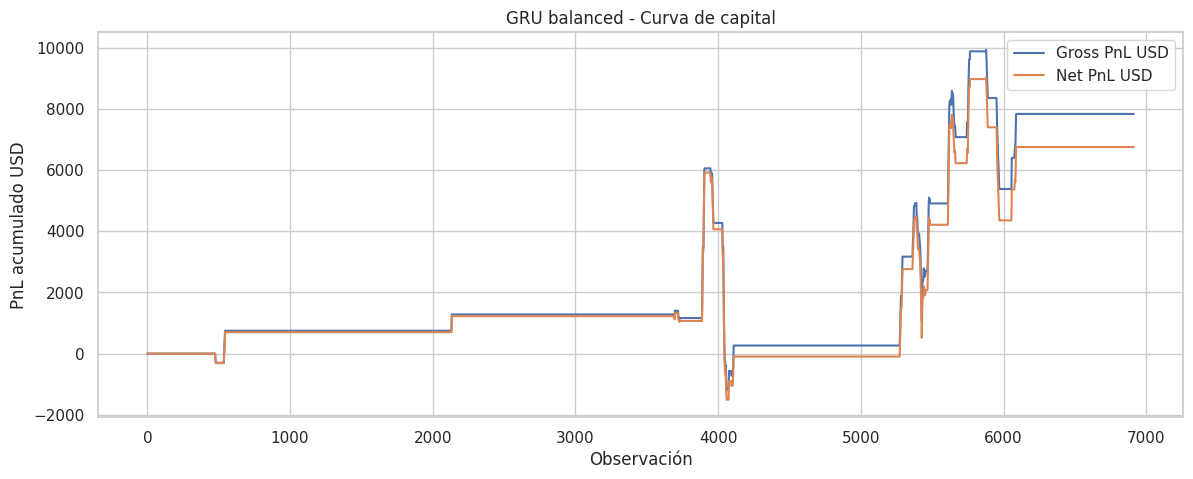

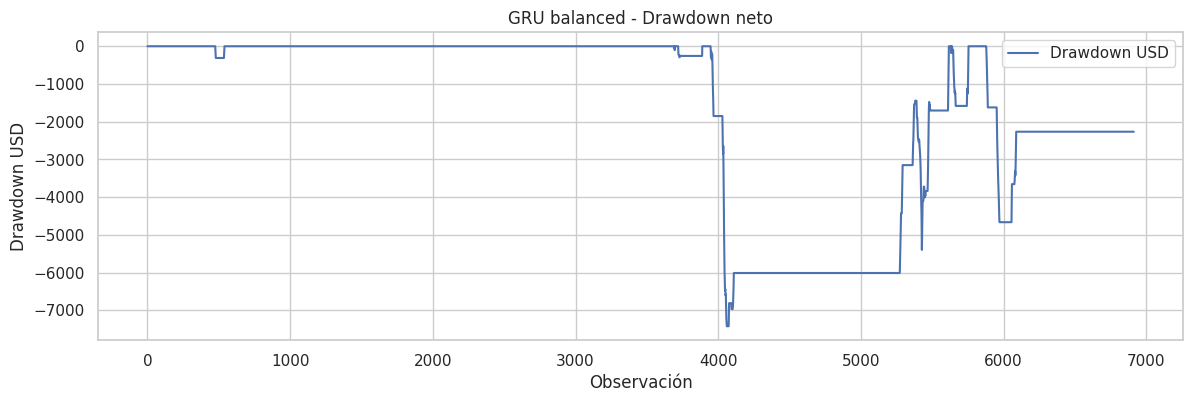

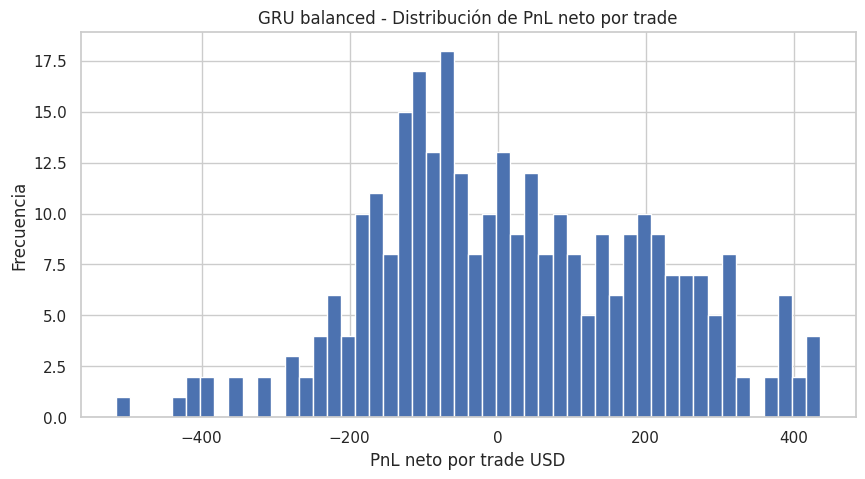

In [21]:
# =========================================================
# 14. Equity curve, drawdown y costos - GRU balanced
# =========================================================

print("=" * 80)
print("EVALUACIÓN ECONÓMICA - GRU BALANCED")
print("=" * 80)

# ---------------------------------------------------------
# 14.1. Parámetros económicos MNQ
# ---------------------------------------------------------

POINT_VALUE_USD = 2.0      # MNQ: 1 punto = 2 USD por contrato
N_CONTRACTS = 1

COMMISSION_PER_SIDE_USD = 1.25
SLIPPAGE_POINTS_PER_SIDE = 0.25

COST_PER_TRADE_USD = (
    2 * COMMISSION_PER_SIDE_USD +
    2 * SLIPPAGE_POINTS_PER_SIDE * POINT_VALUE_USD
) * N_CONTRACTS

print(f"Costo estimado por trade: {COST_PER_TRADE_USD:.2f} USD")


# ---------------------------------------------------------
# 14.2. Construcción de señal GRU balanced en TEST
# ---------------------------------------------------------

thr_long = 0.40
thr_short = 0.45

df_equity = df_test_gru_cmp.copy()

df_equity["signal"] = build_signal(
    df_equity,
    thr_long=thr_long,
    thr_short=thr_short,
)

df_equity["trade"] = df_equity["signal"] != 0


# ---------------------------------------------------------
# 14.3. PnL bruto y neto
# ---------------------------------------------------------

df_equity["pnl_points"] = df_equity["signal"] * df_equity["delta_30"]

df_equity["pnl_usd_gross"] = (
    df_equity["pnl_points"] * POINT_VALUE_USD * N_CONTRACTS
)

df_equity["cost_usd"] = np.where(
    df_equity["trade"],
    COST_PER_TRADE_USD,
    0.0
)

df_equity["pnl_usd_net"] = df_equity["pnl_usd_gross"] - df_equity["cost_usd"]

df_equity["cum_pnl_usd_gross"] = df_equity["pnl_usd_gross"].cumsum()
df_equity["cum_pnl_usd_net"] = df_equity["pnl_usd_net"].cumsum()


# ---------------------------------------------------------
# 14.4. Drawdown
# ---------------------------------------------------------

df_equity["equity_peak"] = df_equity["cum_pnl_usd_net"].cummax()
df_equity["drawdown_usd"] = df_equity["cum_pnl_usd_net"] - df_equity["equity_peak"]

max_drawdown_usd = df_equity["drawdown_usd"].min()


# ---------------------------------------------------------
# 14.5. Métricas económicas
# ---------------------------------------------------------

trades = df_equity[df_equity["trade"]].copy()

metrics_economic = {
    "strategy": "GRU balanced",
    "threshold_long": thr_long,
    "threshold_short": thr_short,
    "n_trades": len(trades),
    "gross_pnl_usd": trades["pnl_usd_gross"].sum(),
    "net_pnl_usd": trades["pnl_usd_net"].sum(),
    "mean_gross_pnl_usd": trades["pnl_usd_gross"].mean(),
    "mean_net_pnl_usd": trades["pnl_usd_net"].mean(),
    "win_rate_gross": (trades["pnl_usd_gross"] > 0).mean(),
    "win_rate_net": (trades["pnl_usd_net"] > 0).mean(),
    "max_drawdown_usd": max_drawdown_usd,
    "profit_factor_gross": (
        trades.loc[trades["pnl_usd_gross"] > 0, "pnl_usd_gross"].sum()
        / abs(trades.loc[trades["pnl_usd_gross"] < 0, "pnl_usd_gross"].sum())
    ),
    "profit_factor_net": (
        trades.loc[trades["pnl_usd_net"] > 0, "pnl_usd_net"].sum()
        / abs(trades.loc[trades["pnl_usd_net"] < 0, "pnl_usd_net"].sum())
    ),
}

df_metrics_economic = pd.DataFrame([metrics_economic])

print("=" * 80)
print("MÉTRICAS ECONÓMICAS")
print("=" * 80)

display(df_metrics_economic)


# ---------------------------------------------------------
# 14.6. Curva de equity
# ---------------------------------------------------------

plt.figure(figsize=(14, 5))
plt.plot(df_equity["cum_pnl_usd_gross"], label="Gross PnL USD")
plt.plot(df_equity["cum_pnl_usd_net"], label="Net PnL USD")
plt.title("GRU balanced - Curva de capital")
plt.xlabel("Observación")
plt.ylabel("PnL acumulado USD")
plt.legend()
plt.grid(True)
plt.show()


# ---------------------------------------------------------
# 14.7. Drawdown
# ---------------------------------------------------------

plt.figure(figsize=(14, 4))
plt.plot(df_equity["drawdown_usd"], label="Drawdown USD")
plt.title("GRU balanced - Drawdown neto")
plt.xlabel("Observación")
plt.ylabel("Drawdown USD")
plt.legend()
plt.grid(True)
plt.show()


# ---------------------------------------------------------
# 14.8. Distribución de PnL por trade
# ---------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.hist(trades["pnl_usd_net"], bins=50)
plt.title("GRU balanced - Distribución de PnL neto por trade")
plt.xlabel("PnL neto por trade USD")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

## **Observación**

**Curva de capital (evolución del dinero en el tiempo)**

La curva de capital representa cómo va creciendo o cayendo el dinero a lo largo del tiempo al aplicar la estrategia.

En este caso, la curva muestra un crecimiento positivo, pero no es suave ni constante. Se observan subidas en forma de saltos, seguidas de periodos largos donde el resultado no cambia.

Esto significa que el sistema no genera ganancias de forma continua, sino que depende de momentos específicos donde ocurren varias operaciones exitosas juntas.

En términos simples, el sistema no está “trabajando todo el tiempo”, sino que aprovecha ciertas oportunidades puntuales del mercado.

---

**Drawdown (caídas desde el máximo)**

El drawdown es la caída desde un máximo previo del capital. Es decir, cuánto dinero se pierde desde un punto alto antes de volver a recuperarse.

En este caso, el drawdown máximo es cercano a -7000 USD, lo cual es significativo.

Además, esta caída ocurre de forma concentrada en un periodo específico, no de manera gradual. Esto indica que el sistema puede sufrir pérdidas fuertes en poco tiempo.

Aunque el sistema es rentable en general, este tipo de caídas implica un nivel de riesgo elevado.

---

**Distribución de resultados por operación**

La distribución muestra cuánto se gana o pierde en cada operación individual.

Se observa que:

* existen pérdidas importantes (por ejemplo, cercanas a -400 USD)
* también existen ganancias importantes (cercanas a +400 USD)

Esto indica que el sistema no gana por acertar muchas veces, sino por el tamaño de sus ganancias cuando acierta.

En otras palabras, puede perder varias veces, pero cuando gana, lo hace con mayor magnitud.

A esto se le llama “asimetría”: las ganancias son mayores que las pérdidas, aunque no necesariamente más frecuentes.

---

**Lectura global**

El sistema presenta características positivas y negativas:

Aspectos positivos:

* el resultado total es positivo, lo que indica que el sistema tiene ventaja (es decir, genera más ganancias que pérdidas en el largo plazo)
* algunas operaciones generan ganancias significativas

Aspectos negativos:

* las caídas (drawdowns) son grandes
* el resultado depende de ciertos periodos específicos de buen desempeño

---

**Problema principal**

El principal problema no está en el modelo en sí, sino en la falta de control del riesgo.

Actualmente:

* todas las operaciones tienen el mismo tamaño
* no existe un límite claro de pérdida
* no se filtran condiciones de mercado donde el modelo funciona peor

Esto hace que el sistema sea vulnerable a pérdidas grandes.

---

**Conclusión operativa**

El sistema muestra rentabilidad, pero todavía requiere una capa de gestión de riesgo antes de considerarse operable en condiciones reales.

Esto se debe a que:

* puede sufrir pérdidas importantes en poco tiempo
* el crecimiento del capital no es estable

Para que sea operable, es necesario reducir el riesgo y mejorar la estabilidad.

---

**Siguiente paso**

A partir de este punto, el enfoque debe cambiar.

Ya no es necesario seguir ajustando modelos o parámetros. El foco debe estar en mejorar la forma en que se gestionan las operaciones.

Los próximos pasos recomendados son:

1. Filtrar operaciones de menor calidad
   (por ejemplo, usando el nivel de confianza del modelo)

2. Ajustar el tamaño de las posiciones
   (no operar siempre con la misma exposición)

3. Analizar el desempeño según condiciones de mercado
   (para identificar cuándo el modelo funciona mejor o peor)

4. Incorporar mecanismos de control de pérdidas

Este análisis permitirá entender en qué situaciones el sistema falla y cómo hacerlo más robusto.


# **15. Simulación bajo reglas de fondeo**

En esta etapa se evalúa la viabilidad operativa de la estrategia bajo condiciones similares a las utilizadas por empresas de fondeo (prop firms).

El objetivo ya no es únicamente medir rentabilidad, sino analizar si la estrategia puede sobrevivir bajo restricciones reales de riesgo y control de pérdidas.

Para ello, se utilizará la configuración GRU balanced seleccionada previamente, incorporando reglas de evaluación basadas en drawdown y preservación de capital.

Se analizarán dos modalidades principales:

* trailing drawdown intradía
* drawdown end-of-day (EOD)

En ambos casos, la simulación se realizará sobre la curva de equity obtenida en TEST OOS.

La evaluación permitirá estudiar:

* estabilidad del capital
* velocidad de recuperación
* profundidad de las pérdidas
* riesgo de invalidación de la cuenta
* compatibilidad de la estrategia con condiciones reales de fondeo

Esta etapa representa la transición desde una evaluación puramente estadística hacia una evaluación operativa realista, centrada en supervivencia y control de riesgo.


- 15.1. Trailing drawdown intradía
    - 15.1.1. Definición de reglas de evaluación
    - 15.1.2. Simulación del trailing drawdown
    - 15.1.3. Punto de ruptura de cuenta
    - 15.1.4. Análisis de supervivencia

- 15.2. Drawdown End of Day (EOD)
    - 15.2.1. Construcción de equity diaria
    - 15.2.2. Simulación de drawdown EOD
    - 15.2.3. Comparación vs trailing intradía

- 15.3. Conclusiones operativas para fondeo

## **15.1. Trailing drawdown intradía**

### **15.1.1. Definición de reglas de evaluación**

En este paso se simula el comportamiento de la estrategia bajo una regla de trailing drawdown intradía, similar a la utilizada por diversas empresas de fondeo.

La idea central consiste en monitorear continuamente el equity acumulado de la cuenta y establecer un límite dinámico de pérdida basado en el máximo histórico alcanzado.

A medida que la cuenta genera ganancias, el límite de pérdida permitido también se desplaza hacia arriba. Sin embargo, si el equity cae por debajo de dicho límite, la cuenta se considera invalidada.

Este tipo de restricción es especialmente exigente porque:

- penaliza secuencias rápidas de pérdidas
- obliga a mantener estabilidad en la curva de capital
- limita la capacidad de recuperación después de una caída fuerte

La simulación se realizará utilizando la curva de equity neta obtenida previamente para la configuración GRU balanced sobre TEST OOS.

El análisis permitirá identificar:

- el comportamiento dinámico del drawdown
- el punto exacto donde la cuenta hubiese sido invalidada
- la capacidad de supervivencia de la estrategia bajo condiciones reales de fondeo

Esta evaluación es crítica, ya que una estrategia rentable puede no ser viable si presenta drawdowns incompatibles con las reglas de riesgo impuestas por una prop firm.

### **15.1.2. Simulación del trailing drawdown**

En esta etapa se implementa la lógica del trailing drawdown intradía sobre la curva de equity neta generada por la estrategia.

Para cada observación se calcula:

* el equity acumulado de la cuenta
* el máximo histórico alcanzado hasta ese momento
* el nivel dinámico de trailing drawdown permitido
* la distancia actual entre el equity y el límite de pérdida

La simulación permite verificar, en cada instante del recorrido temporal, si la estrategia continúa dentro de los límites permitidos o si hubiese violado las reglas de la cuenta de fondeo.

A diferencia de un drawdown fijo tradicional, el trailing drawdown se mueve junto con los nuevos máximos de equity alcanzados por la estrategia. Esto implica que:

* las ganancias tempranas elevan el nivel mínimo permitido
* una caída posterior puede invalidar la cuenta incluso si el resultado total continúa siendo positivo

El objetivo de esta simulación es analizar la robustez dinámica de la estrategia y determinar si el comportamiento observado en la curva de capital es compatible con restricciones reales de fondeo intradía.


SIMULACIÓN TRAILING DRAWDOWN INTRADÍA
Initial balance : 50,000 USD
Trailing DD      : 2,500 USD
--------------------------------------------------------------------------------
RESULTADO: CUENTA INVALIDADA
Observación breach : 4032
Equity              : 53265.00 USD
Trailing threshold  : 53414.50 USD


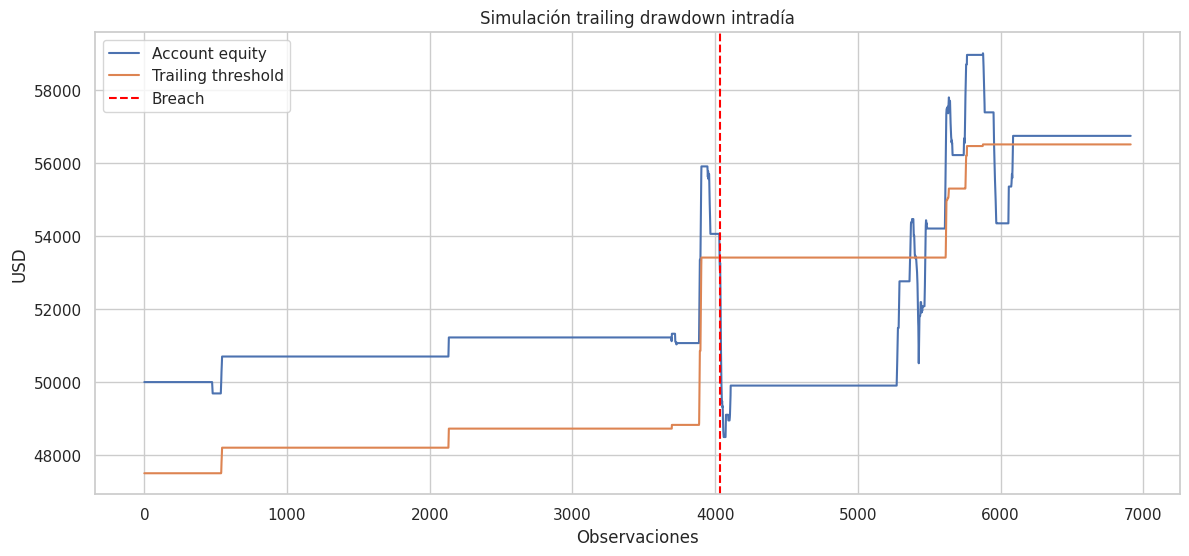

In [22]:
# =========================================================
# 15.1.2. Simulación del trailing drawdown intradía
# =========================================================

print("=" * 80)
print("SIMULACIÓN TRAILING DRAWDOWN INTRADÍA")
print("=" * 80)

# ---------------------------------------------------------
# 1. Parámetros de fondeo
# ---------------------------------------------------------

INITIAL_BALANCE_USD = 50000

# trailing permitido
TRAILING_DD_USD = 2500

print(f"Initial balance : {INITIAL_BALANCE_USD:,.0f} USD")
print(f"Trailing DD      : {TRAILING_DD_USD:,.0f} USD")


# ---------------------------------------------------------
# 2. Construcción de equity real de cuenta
# ---------------------------------------------------------

df_funding = df_equity.copy()

df_funding["account_equity"] = (
    INITIAL_BALANCE_USD +
    df_funding["cum_pnl_usd_net"]
)

# máximo histórico alcanzado
df_funding["equity_peak"] = (
    df_funding["account_equity"].cummax()
)

# trailing threshold dinámico
df_funding["trailing_threshold"] = (
    df_funding["equity_peak"] - TRAILING_DD_USD
)

# distancia al límite
df_funding["distance_to_threshold"] = (
    df_funding["account_equity"] -
    df_funding["trailing_threshold"]
)

# ---------------------------------------------------------
# 3. Detección de breach
# ---------------------------------------------------------

df_funding["breach"] = (
    df_funding["account_equity"] <
    df_funding["trailing_threshold"]
)

breach_exists = df_funding["breach"].any()

print("-" * 80)

if breach_exists:

    breach_idx = df_funding["breach"].idxmax()

    breach_row = df_funding.loc[breach_idx]

    print("RESULTADO: CUENTA INVALIDADA")
    print(f"Observación breach : {breach_idx}")

    print(f"Equity              : {breach_row['account_equity']:.2f} USD")
    print(f"Trailing threshold  : {breach_row['trailing_threshold']:.2f} USD")

else:

    print("RESULTADO: CUENTA SOBREVIVE")


# ---------------------------------------------------------
# 4. Gráfico equity vs trailing threshold
# ---------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    df_funding["account_equity"].values,
    label="Account equity"
)

plt.plot(
    df_funding["trailing_threshold"].values,
    label="Trailing threshold"
)

if breach_exists:

    plt.axvline(
        breach_idx,
        color="red",
        linestyle="--",
        label="Breach"
    )

plt.title("Simulación trailing drawdown intradía")
plt.xlabel("Observaciones")
plt.ylabel("USD")
plt.legend()
plt.grid(True)
plt.show()

### **15.1.3. Punto de ruptura de cuenta**

La simulación muestra que la estrategia GRU balanced no logra sobrevivir bajo una regla de trailing drawdown intradía de 2,500 USD sobre una cuenta inicial de 50,000 USD.

La invalidación ocurre en la observación 4032, momento en el cual:

* el equity de la cuenta cae a 53,265 USD
* el trailing threshold dinámico se encontraba en 53,414.50 USD

Esto implica que la cuenta es invalidada aun cuando el capital continúa por encima del balance inicial.

**Interpretación del resultado**

El problema principal no es la falta de rentabilidad total de la estrategia, sino la dinámica de la curva de capital.

La estrategia logra generar ganancias importantes y elevar el equity de la cuenta hasta nuevos máximos. Sin embargo, al tratarse de un trailing drawdown dinámico, el límite de pérdida permitido también aumenta junto con dichos máximos.

Posteriormente, una corrección relativamente moderada provoca que el equity caiga por debajo del umbral permitido, generando el breach de la cuenta.

Esto evidencia una característica crítica de las reglas de fondeo intradía:

* una estrategia puede ser rentable y aun así fallar operativamente

**Lectura de la curva**

La curva de equity presenta:

* periodos prolongados de estabilidad
* ganancias concentradas en ciertos tramos específicos
* movimientos relativamente abruptos luego de alcanzar nuevos máximos

El breach ocurre inmediatamente después de una expansión rápida del equity, seguida por una caída pronunciada.

Este comportamiento es particularmente riesgoso bajo trailing drawdown intradía, ya que:

* las ganancias elevan rápidamente el trailing threshold
* el margen operativo disponible se reduce
* pequeñas correcciones posteriores pueden invalidar la cuenta

**Insight principal**

El sistema posee capacidad de generar beneficios, pero la volatilidad de la curva de capital sigue siendo demasiado alta para un esquema de trailing intradía agresivo.

En otras palabras:

* el problema no es la expectativa matemática
* el problema es la estabilidad temporal del equity

**Conclusión**

Bajo las condiciones simuladas, la estrategia GRU balanced no supera una evaluación con trailing drawdown intradía de 2,500 USD.

Esto sugiere que:

* el nivel actual de riesgo sigue siendo elevado
* la estrategia requiere mecanismos adicionales de control de drawdown
* la supervivencia depende más de la estabilidad de la curva que del beneficio total acumulado



### **15.1.4. Análisis de supervivencia**


La simulación realizada permite evaluar la capacidad real de supervivencia de la estrategia bajo condiciones estrictas de fondeo intradía.

Aunque la estrategia presenta rentabilidad positiva y logra alcanzar nuevos máximos de equity, el sistema no consigue mantener suficiente estabilidad como para evitar la invalidación de la cuenta.

El análisis evidencia que la supervivencia no depende únicamente de:

* generar beneficios
* tener expectativa positiva
* alcanzar nuevos máximos

sino también de controlar la forma en que evoluciona la curva de capital.

En particular, el trailing drawdown intradía penaliza estrategias con las siguientes características:

* ganancias concentradas en pocos periodos
* alta volatilidad del equity
* correcciones rápidas después de nuevos máximos

La estrategia GRU balanced presenta precisamente este comportamiento:

* logra expandir el capital de forma significativa
* pero posteriormente experimenta retrocesos demasiado agresivos para el margen dinámico permitido

Interpretación operativa

Desde el punto de vista de una empresa de fondeo, el sistema aún presenta un perfil de riesgo elevado.

El problema no es necesariamente la rentabilidad final, sino la incapacidad de mantener una trayectoria suficientemente estable durante el proceso de evaluación.

Esto implica que:

* la estrategia podría generar dinero en una cuenta personal
* pero aun así fallar repetidamente en evaluaciones de fondeo intradía

Insight clave

Las reglas de trailing intradía favorecen estrategias:

* con equity más suave
* con menor volatilidad temporal
* con crecimiento progresivo y estable

No necesariamente favorecen estrategias con mayor beneficio total.

Conclusión

La configuración GRU balanced representa una mejora importante respecto al baseline en términos de estabilidad y calidad de señal, pero todavía no alcanza un nivel de robustez suficiente para superar consistentemente un esquema de trailing drawdown intradía agresivo.

Esto sugiere que el siguiente nivel de mejora debe enfocarse en:

* reducción de drawdown
* suavización de la curva de equity
* control dinámico de exposición
* filtrado de contextos desfavorables

más que en seguir optimizando capacidad predictiva del modelo.

Transición al siguiente análisis

Dado que el trailing intradía representa uno de los escenarios más restrictivos de fondeo, el siguiente paso consiste en evaluar la estrategia bajo un esquema más flexible:

* drawdown End of Day (EOD)

Esto permitirá analizar si la estrategia logra mantener viabilidad cuando las restricciones se aplican sobre cierres diarios y no sobre fluctuaciones intradía temporales.


## **15.2. Drawdown End of Day (EOD)**

En este bloque se evalúa la estrategia bajo una modalidad de control de riesgo más flexible que el trailing drawdown intradía.

A diferencia del trailing intradía, donde la cuenta se monitorea continuamente, el drawdown EOD considera el estado de la cuenta al cierre de cada día.

Esto significa que las fluctuaciones internas del día no invalidan la cuenta mientras el cierre diario se mantenga por encima del límite permitido.

El objetivo de este análisis es verificar si la estrategia GRU balanced puede sobrevivir bajo reglas donde el control de drawdown se aplica sobre la equity diaria y no sobre cada movimiento intradía.

    15.2.1. Construcción de equity diaria
    15.2.2. Simulación de drawdown EOD
    15.2.3. Comparación vs trailing intradía


### **15.2.1. Construcción de equity diaria**

En este paso se transforma la equity intradía en una curva diaria, tomando como referencia el último valor de equity neta disponible para cada día.

Esto permite construir una serie temporal de cierres diarios de la cuenta, que será utilizada para simular el drawdown End of Day.

La finalidad es separar la volatilidad intradía del resultado diario efectivo, evaluando si la estrategia logra mantenerse dentro de los límites cuando solo se considera el cierre de cada jornada.

CONSTRUCCIÓN DE EQUITY DIARIA
Número de días : 223
Max DD diario  : -7422.00 USD
--------------------------------------------------------------------------------


,date,daily_equity,daily_peak,daily_drawdown
0,2025-05-07,50000.0,50000.0,0.0
1,2025-05-08,50000.0,50000.0,0.0
2,2025-05-09,50000.0,50000.0,0.0
3,2025-05-12,50000.0,50000.0,0.0
4,2025-05-13,50000.0,50000.0,0.0


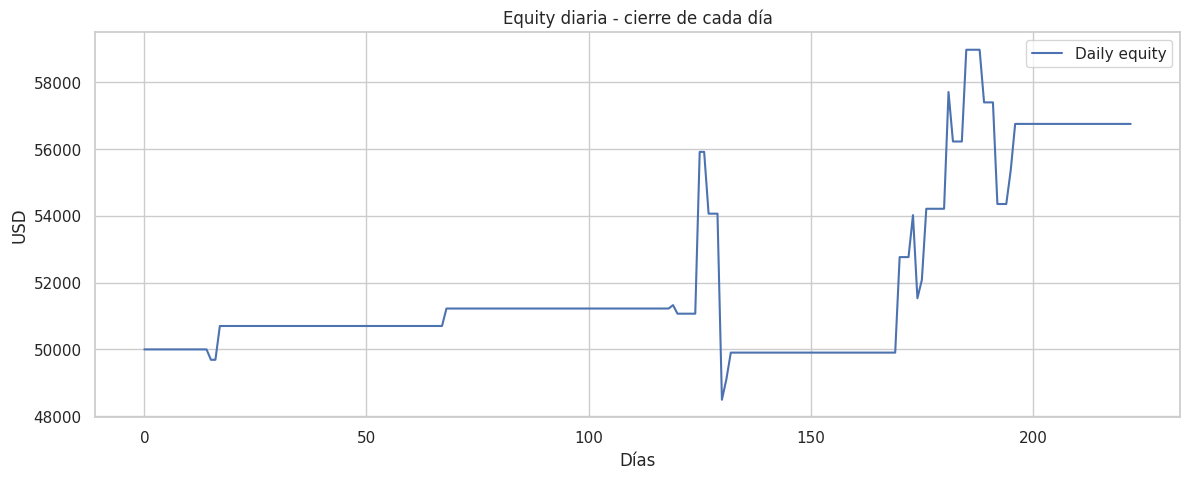

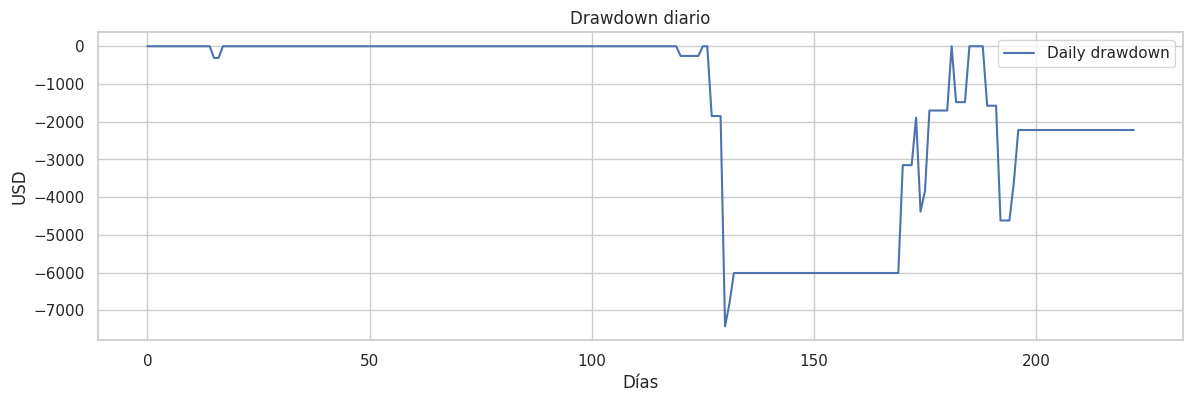

In [23]:
# =========================================================
# 15.2.1. Construcción de equity diaria
# =========================================================

print("=" * 80)
print("CONSTRUCCIÓN DE EQUITY DIARIA")
print("=" * 80)

# ---------------------------------------------------------
# 1. Conversión de fecha
# ---------------------------------------------------------

df_eod = df_funding.copy()

df_eod["date"] = pd.to_datetime(df_eod["date"])


# ---------------------------------------------------------
# 2. Equity al cierre de cada día
# ---------------------------------------------------------

df_daily_equity = (
    df_eod
    .groupby(df_eod["date"].dt.date)
    .agg({
        "account_equity": "last"
    })
    .reset_index()
)

df_daily_equity.columns = [
    "date",
    "daily_equity"
]


# ---------------------------------------------------------
# 3. Peak diario y drawdown diario
# ---------------------------------------------------------

df_daily_equity["daily_peak"] = (
    df_daily_equity["daily_equity"].cummax()
)

df_daily_equity["daily_drawdown"] = (
    df_daily_equity["daily_equity"] -
    df_daily_equity["daily_peak"]
)


# ---------------------------------------------------------
# 4. Resultados básicos
# ---------------------------------------------------------

max_daily_drawdown = (
    df_daily_equity["daily_drawdown"].min()
)

print(f"Número de días : {len(df_daily_equity)}")
print(f"Max DD diario  : {max_daily_drawdown:.2f} USD")

print("-" * 80)

display(df_daily_equity.head())


# ---------------------------------------------------------
# 5. Equity diaria
# ---------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    df_daily_equity["daily_equity"],
    label="Daily equity"
)

plt.title("Equity diaria - cierre de cada día")
plt.xlabel("Días")
plt.ylabel("USD")
plt.legend()
plt.grid(True)
plt.show()


# ---------------------------------------------------------
# 6. Drawdown diario
# ---------------------------------------------------------

plt.figure(figsize=(14, 4))

plt.plot(
    df_daily_equity["daily_drawdown"],
    label="Daily drawdown"
)

plt.title("Drawdown diario")
plt.xlabel("Días")
plt.ylabel("USD")

plt.legend()
plt.grid(True)
plt.show()

### **15.2.2. Simulación de drawdown EOD**

En este paso se aplica la regla de drawdown End of Day sobre la equity diaria construida previamente.

A diferencia del trailing intradía, esta simulación no evalúa cada movimiento interno del día, sino únicamente el valor de cierre diario de la cuenta.

El objetivo es determinar si la estrategia habría sobrevivido bajo una regla donde la invalidación ocurre solo si el equity al cierre del día cae por debajo del límite permitido.

SIMULACIÓN DRAWDOWN END OF DAY (EOD)
Initial balance : 50,000 USD
EOD DD          : 2,500 USD
--------------------------------------------------------------------------------
RESULTADO: CUENTA INVALIDADA EOD
Día breach        : 2025-11-21
Daily equity      : 48492.50 USD
EOD threshold     : 53414.50 USD


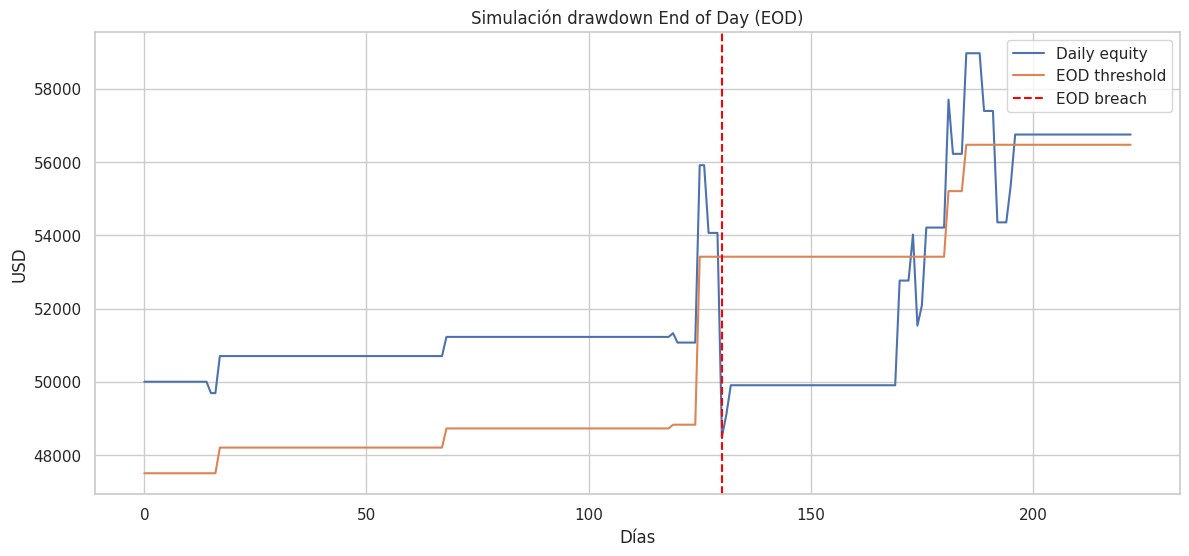

In [24]:
# =========================================================
# 15.2.2. Simulación de drawdown EOD
# =========================================================

print("=" * 80)
print("SIMULACIÓN DRAWDOWN END OF DAY (EOD)")
print("=" * 80)

# ---------------------------------------------------------
# 1. Parámetros de fondeo
# ---------------------------------------------------------

INITIAL_BALANCE_USD = 50000
EOD_DD_USD = 2500

print(f"Initial balance : {INITIAL_BALANCE_USD:,.0f} USD")
print(f"EOD DD          : {EOD_DD_USD:,.0f} USD")

# ---------------------------------------------------------
# 2. Construcción del threshold EOD
# ---------------------------------------------------------

df_eod_sim = df_daily_equity.copy()

df_eod_sim["eod_peak"] = df_eod_sim["daily_equity"].cummax()
df_eod_sim["eod_threshold"] = df_eod_sim["eod_peak"] - EOD_DD_USD

df_eod_sim["distance_to_eod_threshold"] = (
    df_eod_sim["daily_equity"] - df_eod_sim["eod_threshold"]
)

# ---------------------------------------------------------
# 3. Detección de breach EOD
# ---------------------------------------------------------

df_eod_sim["eod_breach"] = (
    df_eod_sim["daily_equity"] < df_eod_sim["eod_threshold"]
)

eod_breach_exists = df_eod_sim["eod_breach"].any()

print("-" * 80)

if eod_breach_exists:

    eod_breach_idx = df_eod_sim["eod_breach"].idxmax()
    eod_breach_row = df_eod_sim.loc[eod_breach_idx]

    print("RESULTADO: CUENTA INVALIDADA EOD")
    print(f"Día breach        : {eod_breach_row['date']}")
    print(f"Daily equity      : {eod_breach_row['daily_equity']:.2f} USD")
    print(f"EOD threshold     : {eod_breach_row['eod_threshold']:.2f} USD")

else:
    print("RESULTADO: CUENTA SOBREVIVE BAJO EOD")

# ---------------------------------------------------------
# 4. Gráfico equity diaria vs threshold EOD
# ---------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    df_eod_sim["daily_equity"].values,
    label="Daily equity"
)

plt.plot(
    df_eod_sim["eod_threshold"].values,
    label="EOD threshold"
)

if eod_breach_exists:
    plt.axvline(
        eod_breach_idx,
        color="red",
        linestyle="--",
        label="EOD breach"
    )

plt.title("Simulación drawdown End of Day (EOD)")
plt.xlabel("Días")
plt.ylabel("USD")
plt.legend()
plt.grid(True)
plt.show()

Observaciones

La cuenta es invalidada bajo la modalidad End of Day, con breach el día 2025-11-21.

En ese momento:

* equity diaria: 48,492.50 USD
* threshold EOD: 53,414.50 USD

Esto indica que la caída diaria fue demasiado profunda respecto al máximo alcanzado previamente.

Interpretación

Aunque el esquema EOD es más flexible que el trailing intradía, la estrategia sigue presentando una caída suficientemente grande como para romper la regla de fondeo.

La diferencia principal es que el EOD no penaliza todas las fluctuaciones intradía, pero sí castiga cierres diarios por debajo del límite permitido.

En este caso, la estrategia alcanzó un pico importante de equity, elevó el threshold y luego cerró con una caída fuerte por debajo del límite.

Conclusión

Bajo un drawdown permitido de 2,500 USD, GRU balanced no sobrevive ni en trailing intradía ni en EOD.

Esto sugiere que el problema no está solo en la modalidad de medición del drawdown, sino en la magnitud de las caídas de la estrategia.

Siguiente paso

Comparar directamente:

* trailing intradía
* drawdown EOD

para entender si EOD mejora la supervivencia o si el nivel de riesgo sigue siendo excesivo.

### **15.2.3. Comparación vs trailing intradía**


La comparación entre ambas modalidades de control de drawdown permite evaluar cómo cambia la viabilidad de la estrategia según el criterio utilizado por la empresa de fondeo.

Resultados observados

Trailing intradía

* La cuenta es invalidada en la observación 4032.
* El breach ocurre poco después de alcanzar un nuevo máximo de equity.
* La invalidación se produce por una corrección relativamente pequeña respecto al pico reciente.

End of Day (EOD)

* La cuenta también es invalidada.
* El breach ocurre el día 2025-11-21.
* La caída relevante ya no corresponde a una fluctuación intradía momentánea, sino a un deterioro suficientemente grande como para afectar el cierre diario de la cuenta.

Interpretación comparativa

El trailing intradía representa un escenario más agresivo y sensible, ya que monitorea continuamente la equity de la cuenta.

Esto implica que:

* pequeñas correcciones temporales pueden invalidar la cuenta
* la estrategia dispone de menor margen operativo
* la volatilidad intradía tiene un impacto crítico

En cambio, el esquema EOD es más flexible porque:

* ignora fluctuaciones temporales dentro del día
* solo considera el equity al cierre diario
* permite cierta recuperación intradía antes de evaluar el drawdown

Sin embargo, en este caso la diferencia no fue suficiente para permitir la supervivencia de la estrategia.

Insight principal

La estrategia no falla únicamente por volatilidad intradía temporal.

El problema central es que existen periodos donde la magnitud de las pérdidas resulta demasiado elevada incluso al cierre diario.

Esto indica que:

* la curva de capital todavía presenta una variabilidad excesiva
* el sistema requiere mecanismos adicionales de estabilización
* la ventaja estadística del modelo no es suficiente por sí sola para cumplir restricciones de fondeo estrictas

Conclusión operativa

La configuración GRU balanced representa una mejora importante respecto al baseline y logra:

* mejor calidad de señal
* mejor estabilidad relativa
* mejor comportamiento económico en TEST

Sin embargo, bajo un límite de drawdown de 2,500 USD:

* no sobrevive trailing intradía
* tampoco sobrevive EOD

Esto sugiere que la estrategia aún necesita:

* reducción de exposición
* control dinámico de tamaño de posición
* filtros de contexto de mercado
* mecanismos de control de pérdidas

antes de considerarse apta para evaluaciones reales de fondeo.




## **15.3. Conclusión general del bloque 15**


El análisis demuestra que la rentabilidad de una estrategia no garantiza su viabilidad operativa bajo reglas reales de prop firms.

La supervivencia depende principalmente de:

* estabilidad temporal de la curva de equity
* control de drawdown
* suavidad del crecimiento del capital

más que del beneficio total acumulado.

# **Cierre de la etapa — Target T2**

A lo largo de esta etapa se desarrolló una evaluación completa del target T2 utilizando modelos de clasificación aplicados a señales intradía del mercado MNQ.

El análisis incluyó:

- entrenamiento y comparación de modelos
- evaluación probabilística
- construcción de señales operativas
- calibración de thresholds
- análisis de robustez out-of-sample
- evaluación económica mediante PnL
- simulación de condiciones reales de fondeo

Resultados principales
----------------------

El modelo GRU logró capturar señal predictiva válida sobre el target T2, obteniendo resultados positivos tanto en métricas de clasificación como en métricas económicas.

Se observó que:

- las probabilidades contienen información útil
- el modelo genera trades con ventaja estadística
- existe capacidad de generar PnL positivo fuera de muestra

Durante el proceso de calibración de thresholds se verificó que:

- thresholds bajos aumentan volumen, pero introducen ruido
- thresholds altos mejoran precisión, pero eliminan demasiadas oportunidades
- la configuración balanced (0.40 / 0.45) representa el mejor compromiso observado entre frecuencia y calidad de señal

En TEST OOS, dicha configuración mostró:

- mejor estabilidad relativa
- mejor PnL promedio
- menor exposición que el baseline

Diagnóstico operativo
---------------------

A pesar de la existencia de edge estadístico, el análisis económico mostró limitaciones importantes desde el punto de vista operativo.

Las simulaciones de equity curve y drawdown evidenciaron que:

- el crecimiento del capital no es estable
- el sistema depende de períodos específicos de buen desempeño
- existen drawdowns significativos
- el riesgo operativo sigue siendo elevado

Posteriormente, al simular reglas reales de fondeo:

- trailing drawdown intradía
- drawdown End of Day (EOD)

la estrategia terminó invalidando la cuenta en ambos escenarios.

Esto indica que:

- el sistema posee capacidad predictiva
- pero todavía no presenta robustez suficiente para operar bajo restricciones estrictas de riesgo

Conclusión conceptual
---------------------

El principal hallazgo de esta etapa es que:

el problema ya no está en el modelo.

El modelo logra generar señal útil.

La limitación principal aparece en el diseño del target y en la estructura operativa derivada de ese target.

El target T2 permite identificar dirección futura del mercado, pero no necesariamente operaciones compatibles con restricciones reales de trading y fondeo.

En particular, el target no incorpora explícitamente:

- relación riesgo/beneficio
- control de pérdidas
- stops operativos
- recorridos adversos
- dinámica real de ejecución

Como consecuencia, el sistema puede generar operaciones correctas desde el punto de vista direccional, pero económicamente inestables.

Conclusión final de la etapa
----------------------------

La investigación sobre T2 puede considerarse exitosa como etapa exploratoria y de validación metodológica.

Se logró:

- construir un pipeline completo de entrenamiento y evaluación
- validar capacidad predictiva real OOS
- desarrollar métricas operativas y económicas
- simular restricciones reales de fondeo

Sin embargo, los resultados obtenidos indican que continuar optimizando thresholds o hiperparámetros sobre T2 probablemente produzca mejoras marginales.

El siguiente avance lógico del proyecto consiste en redefinir el target.

Próxima etapa recomendada
-------------------------

Se propone avanzar hacia targets más operativos, orientados explícitamente a gestión de trades y control de riesgo.

En particular:

- targets basados en TP/SL
- targets condicionados por recorrido favorable/adverso
- targets dependientes de riesgo máximo permitido
- targets compatibles con reglas reales de fondeo

Esto permitirá trasladar el aprendizaje desde:

predicción de dirección

hacia:

predicción de operaciones económicamente viables.

De esta forma, la siguiente etapa del proyecto buscará no solo detectar movimiento futuro del mercado, sino identificar trades capaces de sobrevivir bajo condiciones reales de operación profesional.